# Bayesian Network Structure Learning — POC Experiment

Compares **Hill Climbing** (pgmpy) against **NOTEARS** (gcastle) in two feature regimes:
- Low-dimensional: 10 features, 1000 samples
- High-dimensional: 100 features, 1000 samples

Each dataset is split 90/10 into train/test. We measure wall-clock time for structure learning.

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from data import *
from reporting import graph_metrics, plot_dag
from training import *
import pandas as pd



SEED = 42


## Training

In [21]:
sachs_df, sachs_dag  = load_sachs()
print(f"Sachs: {sachs_df.shape[0]} samples, {sachs_df.shape[1]} nodes, {len(sachs_dag.edges())} true edges")

sachs_notears_result = train_notears(sachs_df, lambda1=0.1, w_threshold=0.6)
sachs_notears_metrics = graph_metrics(sachs_dag.edges, sachs_notears_result.edges)
sachs_daggnn_result = train_daggnn(sachs_df, mlp_dimension=64, epochs=100, lr=0.003, graph_threshold=0.3)
sachs_daggnn_metrics = graph_metrics(sachs_dag.edges, sachs_daggnn_result.edges)

sachs_hc_result = train_hill_climbing(sachs_df)
sachs_hc_metrics = graph_metrics(sachs_dag.edges, sachs_hc_result.edges)
sachs_pc_result = train_pc(sachs_df, ci_test="pearsonr", significance_level=0.001, max_cond_vars=None)
sachs_pc_metrics = graph_metrics(sachs_dag.edges, sachs_pc_result.edges)
sachs_fges_result = train_fges(sachs_df, method="r2")
sachs_fges_metrics = graph_metrics(sachs_dag.edges, sachs_fges_result.edges)


2026-07-06 13:47:21,365 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:195] - INFO: [start]: n=11672, d=11, iter_=100, h_=1e-08, rho_=10000000000000000


Sachs: 11672 samples, 11 nodes, 20 true edges


2026-07-06 13:47:23,407 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 0] h=2.495e+00, loss=543643.397, rho=1.0e+00
2026-07-06 13:47:23,471 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.493e+00, loss=259291.045, rho=1.0e+00
2026-07-06 13:47:23,639 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.464e+00, loss=259319.053, rho=1.0e+01
2026-07-06 13:47:24,514 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.251e+00, loss=259599.133, rho=1.0e+02
2026-07-06 13:47:25,676 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradie

In [6]:
CANCER_SAMPLES = 1000
cancer_df, cancer_dag  = load_cancer(CANCER_SAMPLES, seed=SEED)
print(f"cancer: {cancer_df.shape[0]} samples, {cancer_df.shape[1]} nodes, {len(cancer_dag.edges())} true edges")

cancer_notears_result = train_notears(cancer_df, lambda1=0.01, w_threshold=0.0)
cancer_notears_metrics = graph_metrics(cancer_dag.edges, cancer_notears_result.edges)
cancer_daggnn_result = train_daggnn(cancer_df, mlp_dimension=32, epochs=100, lr=0.003, graph_threshold=0.05)
cancer_daggnn_metrics = graph_metrics(cancer_dag.edges, cancer_daggnn_result.edges)

cancer_hc_result = train_hill_climbing(cancer_df)
cancer_hc_metrics = graph_metrics(cancer_dag.edges, cancer_hc_result.edges)
cancer_pc_result = train_pc(cancer_df, ci_test="pearsonr", significance_level=0.005, max_cond_vars=None)
cancer_pc_metrics = graph_metrics(cancer_dag.edges, cancer_pc_result.edges)
cancer_fges_result = train_fges(cancer_df, method="scatter")
cancer_fges_metrics = graph_metrics(cancer_dag.edges, cancer_fges_result.edges)


Generating for node: Dyspnoea: 100%|██████████| 5/5 [00:00<00:00, 742.72it/s]
2026-07-06 12:59:07,861 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:195] - INFO: [start]: n=1000, d=5, iter_=100, h_=1e-08, rho_=10000000000000000
2026-07-06 12:59:07,869 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 0] h=8.105e-07, loss=0.347, rho=1.0e+00
2026-07-06 12:59:07,871 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=8.105e-07, loss=0.347, rho=1.0e+00
2026-07-06 12:59:07,874 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=8.105e-07, loss=0.347, rho=1.0e+01
2026-07-06 12:59:07,877 - /home/danie/codice/uni/b

cancer: 1000 samples, 5 nodes, 4 true edges


2026-07-06 12:59:12,249 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 0, epoch: 99, h_new: 0.0011701504513990102
2026-07-06 12:59:16,551 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 1, epoch: 99, h_new: 0.0011701504513990102
2026-07-06 12:59:29,341 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 2, epoch: 99, h_new: 0.00014469971200536946
2026-07-06 12:59:37,984 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 3, epoch: 99, h_new: 2.9209005552033318e-05
2026-07-06 12:59:46,646 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/ca

In [7]:
CHILD_SAMPLES = 1000
child_df, child_dag  = load_child(CHILD_SAMPLES, seed=SEED)
print(f"child: {child_df.shape[0]} samples, {child_df.shape[1]} nodes, {len(child_dag.edges())} true edges")

child_notears_result = train_notears(child_df, lambda1=0.05, w_threshold=0.3)
child_notears_metrics = graph_metrics(child_dag.edges, child_notears_result.edges)
child_daggnn_result = train_daggnn(child_df, mlp_dimension=32, epochs=100, lr=0.003, graph_threshold=0.3)
child_daggnn_metrics = graph_metrics(child_dag.edges, child_daggnn_result.edges)

child_hc_result = train_hill_climbing(child_df)
child_hc_metrics = graph_metrics(child_dag.edges, child_hc_result.edges)
child_pc_result = train_pc(child_df, ci_test="pearsonr", significance_level=0.001, max_cond_vars=None)
child_pc_metrics = graph_metrics(child_dag.edges, child_pc_result.edges)
child_fges_result = train_fges(child_df, method="scatter")
child_fges_metrics = graph_metrics(child_dag.edges, child_fges_result.edges)



Generating for node: ChestXray:   0%|          | 0/20 [00:00<?, ?it/s]  2026-07-06 13:00:35,086 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/utils/mathext.py[line:90] - WARNING: Probability values don't exactly sum to 1. Differ by: -2.220446049250313e-16. Adjusting values.
2026-07-06 13:00:35,086 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/utils/mathext.py[line:90] - WARNING: Probability values don't exactly sum to 1. Differ by: 2.220446049250313e-16. Adjusting values.
Generating for node: GruntingReport: 100%|██████████| 20/20 [00:00<00:00, 463.45it/s]
2026-07-06 13:00:35,116 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:195] - INFO: [start]: n=1000, d=20, iter_=100, h_=1e-08, rho_=10000000000000000
2026-07-06 13:00:35,180 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/g

child: 1000 samples, 20 nodes, 25 true edges


2026-07-06 13:00:35,415 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=3.298e-02, loss=7.351, rho=1.0e+02
2026-07-06 13:00:35,483 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 2] h=1.955e-02, loss=4.978, rho=1.0e+02
2026-07-06 13:00:35,590 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 2] h=7.515e-03, loss=5.467, rho=1.0e+03
2026-07-06 13:00:35,663 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 3] h=4.533e-03, loss=5.068, rho=1.0e+03
2026-07-06 13:00:35,790 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py

In [ ]:
ALARM_SAMPLES = 1000
alarm_df, alarm_dag = load_alarm(ALARM_SAMPLES, seed=SEED)
print(f"alarm: {alarm_df.shape[0]} samples, {alarm_df.shape[1]} nodes, {len(alarm_dag.edges())} true edges")

alarm_notears_result = train_notears(alarm_df, lambda1=0.01, w_threshold=0.2)
alarm_notears_metrics = graph_metrics(alarm_dag.edges, alarm_notears_result.edges)
alarm_daggnn_result = train_daggnn(alarm_df, mlp_dimension=32, epochs=300, lr=0.003, graph_threshold=0.3)
alarm_daggnn_metrics = graph_metrics(alarm_dag.edges, alarm_daggnn_result.edges)

alarm_hc_result = train_hill_climbing(alarm_df)
alarm_hc_metrics = graph_metrics(alarm_dag.edges, alarm_hc_result.edges)
alarm_pc_result = train_pc(alarm_df, ci_test="pearsonr", significance_level=0.01, max_cond_vars=None)
alarm_pc_metrics = graph_metrics(alarm_dag.edges, alarm_pc_result.edges)
alarm_fges_result = train_fges(alarm_df, method="scatter")
alarm_fges_metrics = graph_metrics(alarm_dag.edges, alarm_fges_result.edges)


Generating for node: BP: 100%|██████████| 37/37 [00:00<00:00, 568.04it/s]
2026-07-06 13:02:37,540 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:195] - INFO: [start]: n=1000, d=37, iter_=100, h_=1e-08, rho_=10000000000000000


alarm: 1000 samples, 37 nodes, 46 true edges


2026-07-06 13:02:38,136 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 0] h=3.143e-01, loss=6.944, rho=1.0e+00
2026-07-06 13:02:38,524 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.102e-01, loss=3.352, rho=1.0e+00
2026-07-06 13:02:39,286 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=9.108e-02, loss=3.797, rho=1.0e+01
2026-07-06 13:02:40,013 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=3.008e-02, loss=8.242, rho=1.0e+02
2026-07-06 13:02:40,614 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py

## Performance graphs

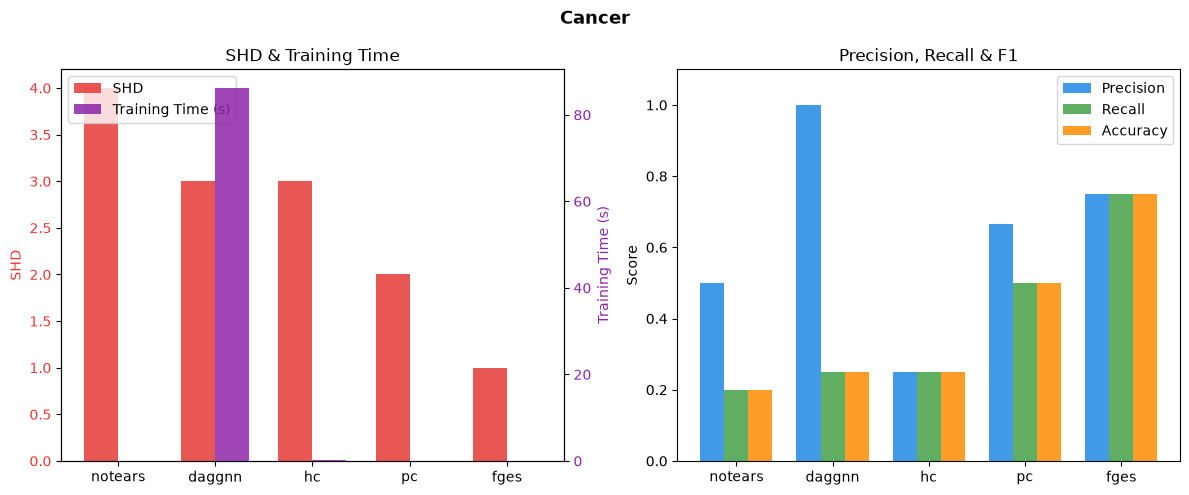

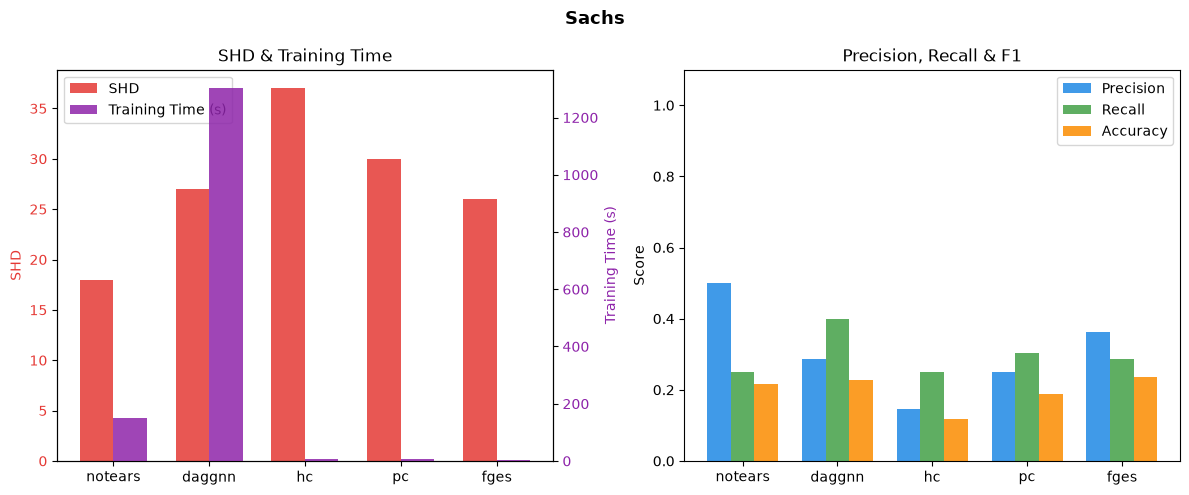

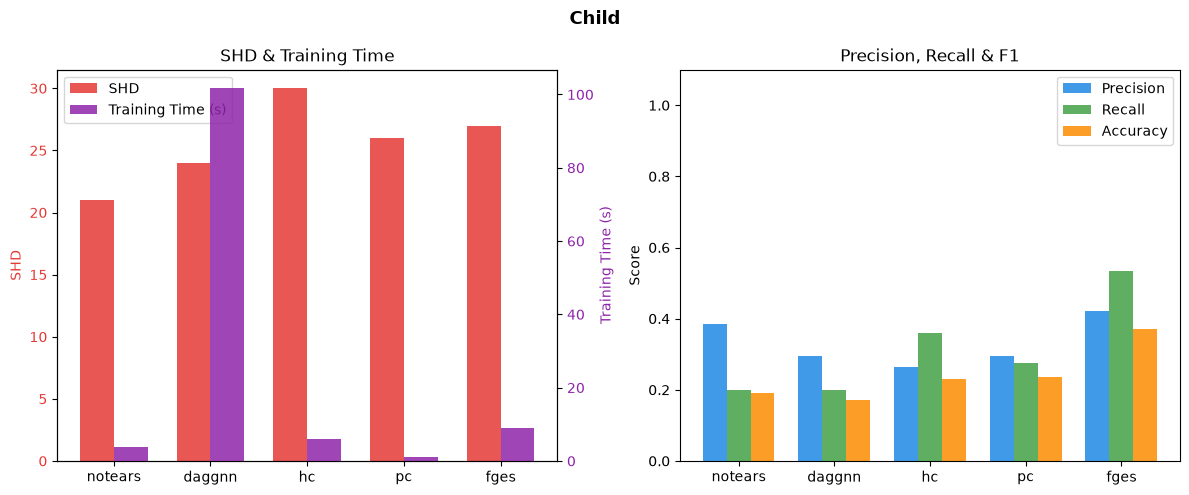

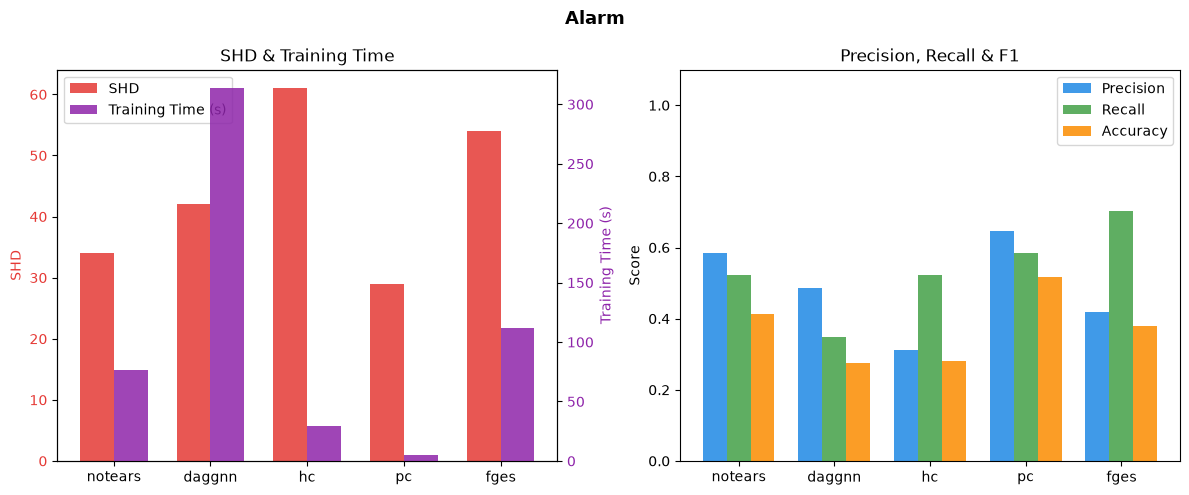

In [33]:
datasets = {
    "Cancer": {
        "notears": (cancer_notears_metrics, cancer_notears_result.elapsed_s),
        "daggnn":  (cancer_daggnn_metrics,  cancer_daggnn_result.elapsed_s),
        "hc":      (cancer_hc_metrics,      cancer_hc_result.elapsed_s),
        "pc":      (cancer_pc_metrics,      cancer_pc_result.elapsed_s),
        "fges":    (cancer_fges_metrics,    cancer_fges_result.elapsed_s),
    },
    "Sachs": {
        "notears": (sachs_notears_metrics,  sachs_notears_result.elapsed_s),
        "daggnn":  (sachs_daggnn_metrics,   sachs_daggnn_result.elapsed_s),
        "hc":      (sachs_hc_metrics,       sachs_hc_result.elapsed_s),
        "pc":      (sachs_pc_metrics,       sachs_pc_result.elapsed_s),
        "fges":    (sachs_fges_metrics,     sachs_fges_result.elapsed_s),
    },
    "Child": {
        "notears": (child_notears_metrics,  child_notears_result.elapsed_s),
        "daggnn":  (child_daggnn_metrics,   child_daggnn_result.elapsed_s),
        "hc":      (child_hc_metrics,       child_hc_result.elapsed_s),
        "pc":      (child_pc_metrics,       child_pc_result.elapsed_s),
        "fges":    (child_fges_metrics,     child_fges_result.elapsed_s),
    },
    "Alarm": {
        "notears": (alarm_notears_metrics,  alarm_notears_result.elapsed_s),
        "daggnn":  (alarm_daggnn_metrics,   alarm_daggnn_result.elapsed_s),
        "hc":      (alarm_hc_metrics,       alarm_hc_result.elapsed_s),
        "pc":      (alarm_pc_metrics,       alarm_pc_result.elapsed_s),
        "fges":    (alarm_fges_metrics,     alarm_fges_result.elapsed_s),
        # fges: does not terminate on 37-node datasets
    },
}

ALGORITHMS  = [
    "notears",
    "daggnn",
    "hc",
    "pc",
    "fges"
]
SHD_COLOR   = "#E53935"
TIME_COLOR  = "#8E24AA"
PRF_COLORS  = {"precision": "#1E88E5", "recall": "#43A047", "accuracy": "#FB8C00"}


def _plot_dataset(title, algo_data):
    fig, (ax_shd_time, ax_prf) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    x = np.arange(len(ALGORITHMS))
    w = 0.35

    # left: SHD (left axis) + training time (right axis)
    ax_time = ax_shd_time.twinx()

    shd_vals  = [algo_data[a][0]["shd"] if a in algo_data else float("nan") for a in ALGORITHMS]
    time_vals = [algo_data[a][1]        if a in algo_data else float("nan") for a in ALGORITHMS]

    b_shd  = ax_shd_time.bar(x - w / 2, shd_vals,  w, color=SHD_COLOR,  alpha=0.85, label="SHD")
    b_time = ax_time.bar(    x + w / 2, time_vals, w, color=TIME_COLOR, alpha=0.85, label="Training Time (s)")

    ax_shd_time.set_xticks(x)
    ax_shd_time.set_xticklabels(ALGORITHMS)
    ax_shd_time.set_ylabel("SHD",              color=SHD_COLOR)
    ax_shd_time.tick_params(axis="y",           labelcolor=SHD_COLOR)
    ax_time.set_ylabel("Training Time (s)",     color=TIME_COLOR)
    ax_time.tick_params(axis="y",               labelcolor=TIME_COLOR)
    ax_shd_time.set_title("SHD & Training Time")
    ax_shd_time.legend(handles=[b_shd, b_time], loc="upper left")

    # right: precision, recall, F1
    w3 = 0.25
    offsets = [-w3, 0, w3]
    for (metric, color), offset in zip(PRF_COLORS.items(), offsets):
        vals = [algo_data[a][0][metric] if a in algo_data else float("nan") for a in ALGORITHMS]
        ax_prf.bar(x + offset, vals, w3, color=color, alpha=0.85, label=metric.capitalize())

    ax_prf.set_xticks(x)
    ax_prf.set_xticklabels(ALGORITHMS)
    ax_prf.set_ylabel("Score")
    ax_prf.set_ylim(0, 1.1)
    ax_prf.set_title("Precision, Recall & F1")
    ax_prf.legend()

    fig.tight_layout()
    plt.show()


for name, algo_data in datasets.items():
    _plot_dataset(name, algo_data)



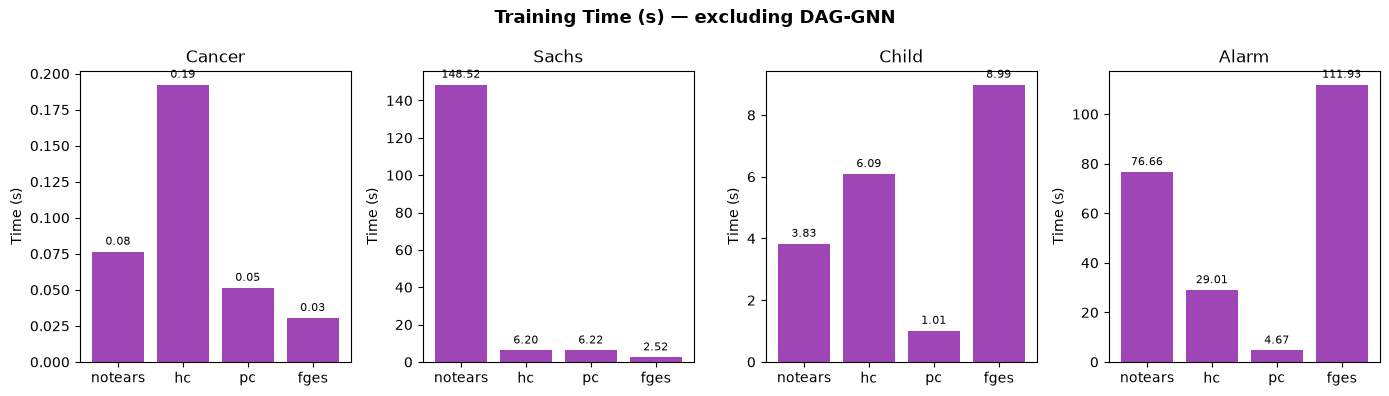

In [34]:
ALGOS_NO_DAGGNN = [a for a in ALGORITHMS if a != "daggnn"]

fig, axes = plt.subplots(1, len(datasets), figsize=(14, 4), sharey=False)
fig.suptitle("Training Time (s) — excluding DAG-GNN", fontsize=13, fontweight="bold")

for ax, (ds_name, algo_data) in zip(axes, datasets.items()):
    x = np.arange(len(ALGOS_NO_DAGGNN))
    times = [algo_data.get(a, (0,0))[1] for a in ALGOS_NO_DAGGNN]
    bars = ax.bar(x, times, color=TIME_COLOR, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(ALGOS_NO_DAGGNN)
    ax.set_title(ds_name)
    ax.set_ylabel("Time (s)")
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)

fig.tight_layout()
plt.show()


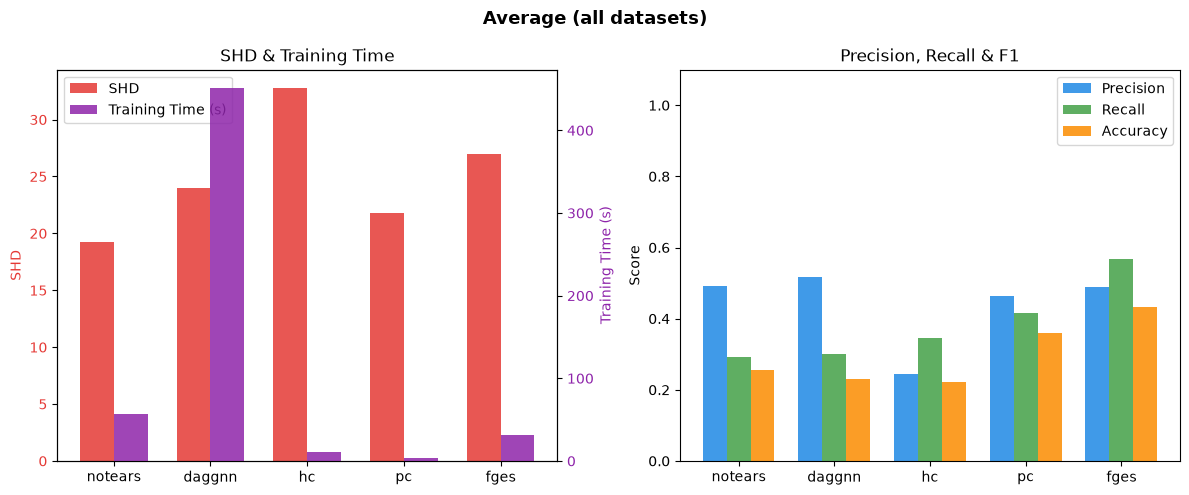

In [35]:
# aggregate figure — average only over datasets where the algorithm was run
avg_data = {
    algo: (
        {m: np.mean([datasets[ds][algo][0][m] for ds in datasets if algo in datasets[ds]])
         for m in ["shd", "shd_normalized", "precision", "recall", "accuracy"]},
        np.mean([datasets[ds][algo][1] for ds in datasets if algo in datasets[ds]]),
    )
    for algo in ALGORITHMS
}
_plot_dataset("Average (all datasets)", avg_data)

In [36]:

def _accuracy(m):
    denom = m["tp"] + m["fp"] + m["fn"] + m["reversed"]
    return m["tp"] / denom if denom > 0 else 0.0

rows = []

for ds_name, algo_data in datasets.items():
    for algo in ALGORITHMS:
        if algo not in algo_data:
            continue
        m, elapsed = algo_data[algo]
        rows.append({
            "Dataset":   ds_name,
            "Algorithm": algo.upper(),
            "Time (s)":  round(elapsed, 2),
            "SHD":       m["shd"],
            "nSHD":       m["shd_normalized"],
            "Accuracy":  round(_accuracy(m), 3),
            "Precision": round(m["precision"], 3),
            "Recall":    round(m["recall"], 3),
            "F1":        round(m["f1"], 3),
        })

for algo in ALGORITHMS:
    present = [ds for ds in datasets if algo in datasets[ds]]
    if not present:
        continue
    ms = [datasets[ds][algo][0] for ds in present]
    rows.append({
        "Dataset":   "Average",
        "Algorithm": algo.upper(),
        "Time (s)":  round(np.mean([datasets[ds][algo][1] for ds in present]), 2),
        "SHD":       round(np.mean([m["shd"] for m in ms]), 1),
        "nSHD":      round(np.mean([m["shd_normalized"] for m in ms]), 1),
        "Accuracy":  round(np.mean([_accuracy(m) for m in ms]), 3),
        "Precision": round(np.mean([m["precision"] for m in ms]), 3),
        "Recall":    round(np.mean([m["recall"] for m in ms]), 3),
        "F1":        round(np.mean([m["f1"] for m in ms]), 3),
    })

summary_df = pd.DataFrame(rows).set_index(["Dataset", "Algorithm"])
summary_df


Time (s)   SHD      nSHD  Accuracy  Precision  Recall  \
Dataset Algorithm                                                          
Cancer  NOTEARS        0.08   4.0  1.000000     0.200      0.500   0.200   
        DAGGNN        86.19   3.0  0.750000     0.250      1.000   0.250   
        HC             0.19   3.0  0.750000     0.250      0.250   0.250   
        PC             0.05   2.0  0.500000     0.500      0.667   0.500   
        FGES           0.03   1.0  0.250000     0.750      0.750   0.750   
Sachs   NOTEARS      148.52  18.0  0.900000     0.217      0.500   0.250   
        DAGGNN      1302.20  27.0  1.350000     0.229      0.286   0.400   
        HC             6.20  37.0  1.850000     0.119      0.147   0.250   
        PC             6.22  30.0  1.500000     0.189      0.250   0.304   
        FGES           2.52  26.0  1.300000     0.235      0.364   0.286   
Child   NOTEARS        3.83  21.0  0.840000     0.192      0.385   0.200   
        DAGGNN       101.69  24.0  0.960000     0.172      0.294   0.200   
        HC             6.09  30.0  1.200000     0.231      0.265   0.360   
        PC             1.01  26.0  1.040000     0.235      0.296   0.276   
        FGES           8.99  27.0  1.080000     0.372      0.421   0.533   
Alarm   NOTEARS       76.66  34.0  0.739130     0.414      0.585   0.522   
        DAGGNN       313.45  42.0  0.913043     0.276      0.485   0.348   
        HC            29.01  61.0  1.326087     0.282      0.312   0.522   
        PC             4.67  29.0  0.630435     0.517      0.646   0.585   
        FGES         111.93  54.0  1.173913     0.379      0.418   0.702   
Average NOTEARS       57.27  19.2  0.900000     0.256      0.492   0.293   
        DAGGNN       450.88  24.0  1.000000     0.232      0.516   0.299   
        HC            10.37  32.8  1.300000     0.221      0.243   0.345   
        PC             2.99  21.8  0.900000     0.360      0.465   0.416   
        FGES          30.87  27.0  1.000000     0.434      0.488   0.568   

                      F1  
Dataset Algorithm         
Cancer  NOTEARS    0.286  
        DAGGNN     0.400  
        HC         0.250  
        PC         0.571  
        FGES       0.750  
Sachs   NOTEARS    0.333  
        DAGGNN     0.333  
        HC         0.185  
        PC         0.275  
        FGES       0.320  
Child   NOTEARS    0.263  
        DAGGNN     0.238  
        HC         0.305  
        PC         0.286  
        FGES       0.471  
Alarm   NOTEARS    0.552  
        DAGGNN     0.405  
        HC         0.390  
        PC         0.614  
        FGES       0.524  
Average NOTEARS    0.358  
        DAGGNN     0.344  
        HC         0.283  
        PC         0.436  
        FGES       0.516

## Images of the original DAG compared to the reconstructed ones

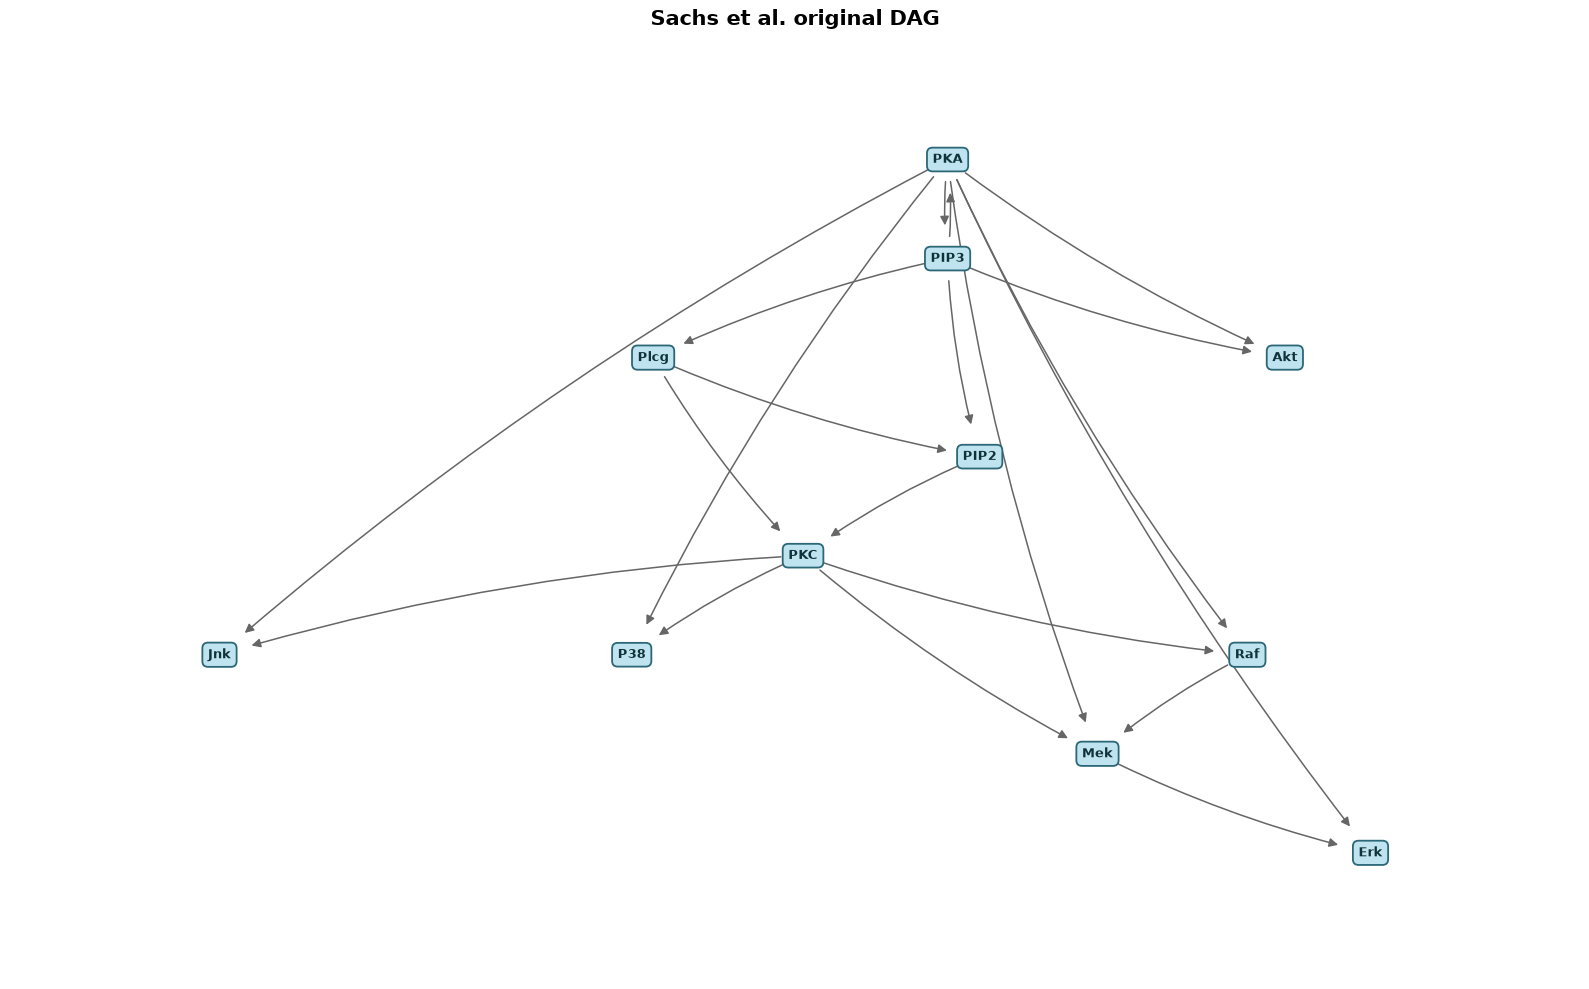

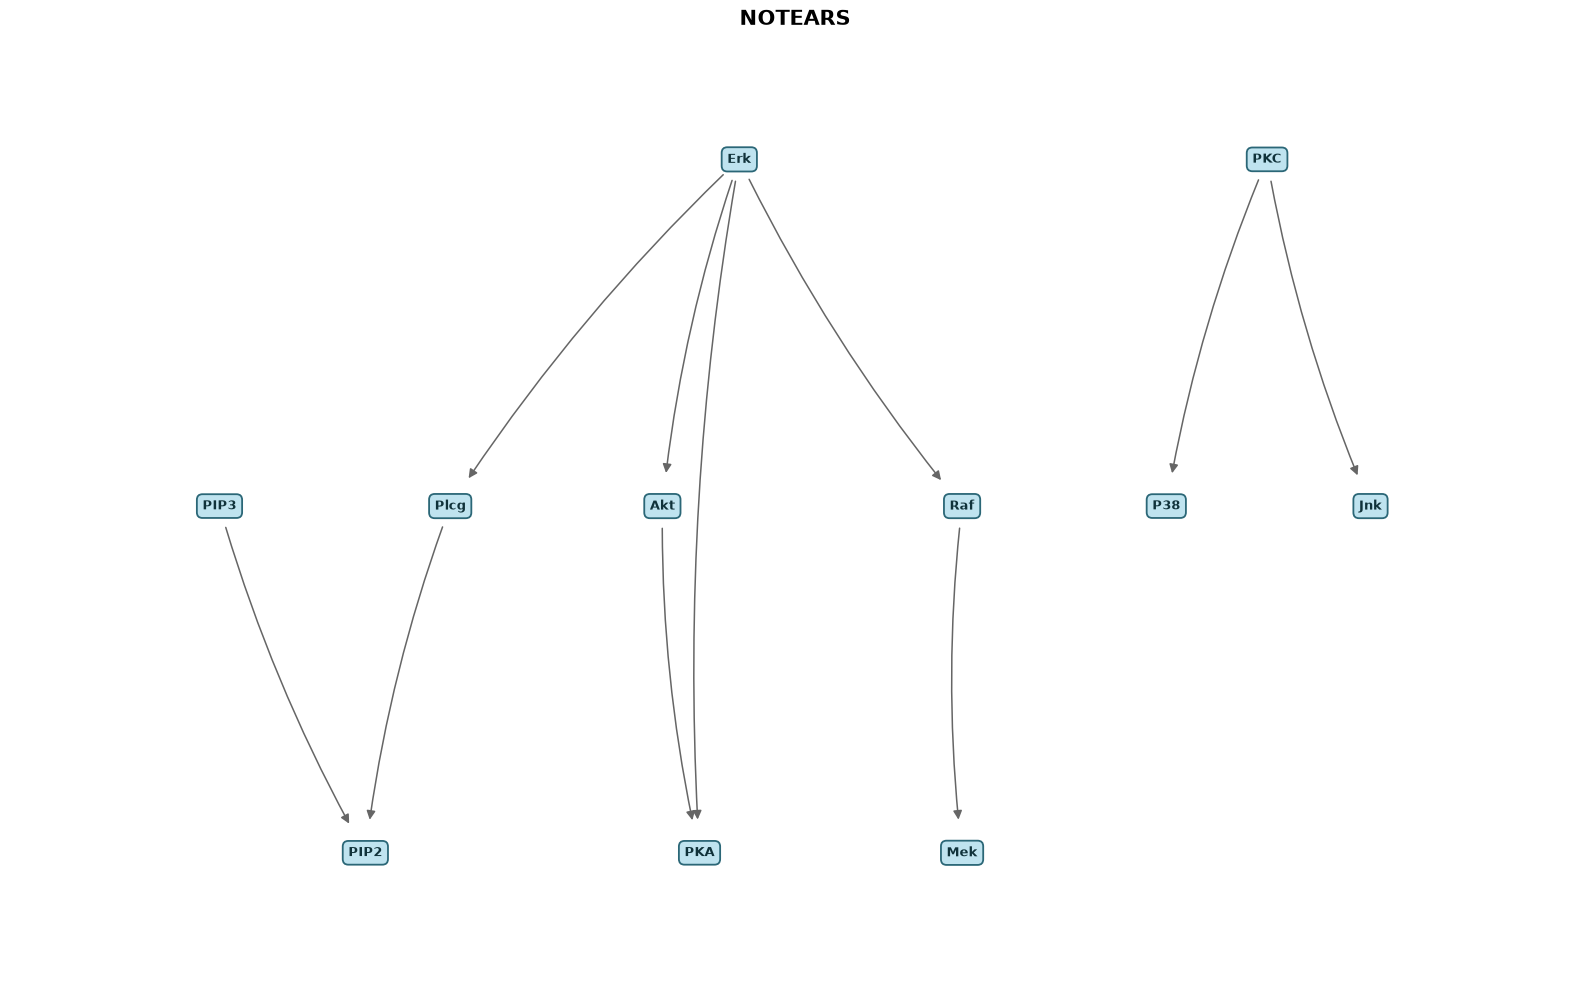

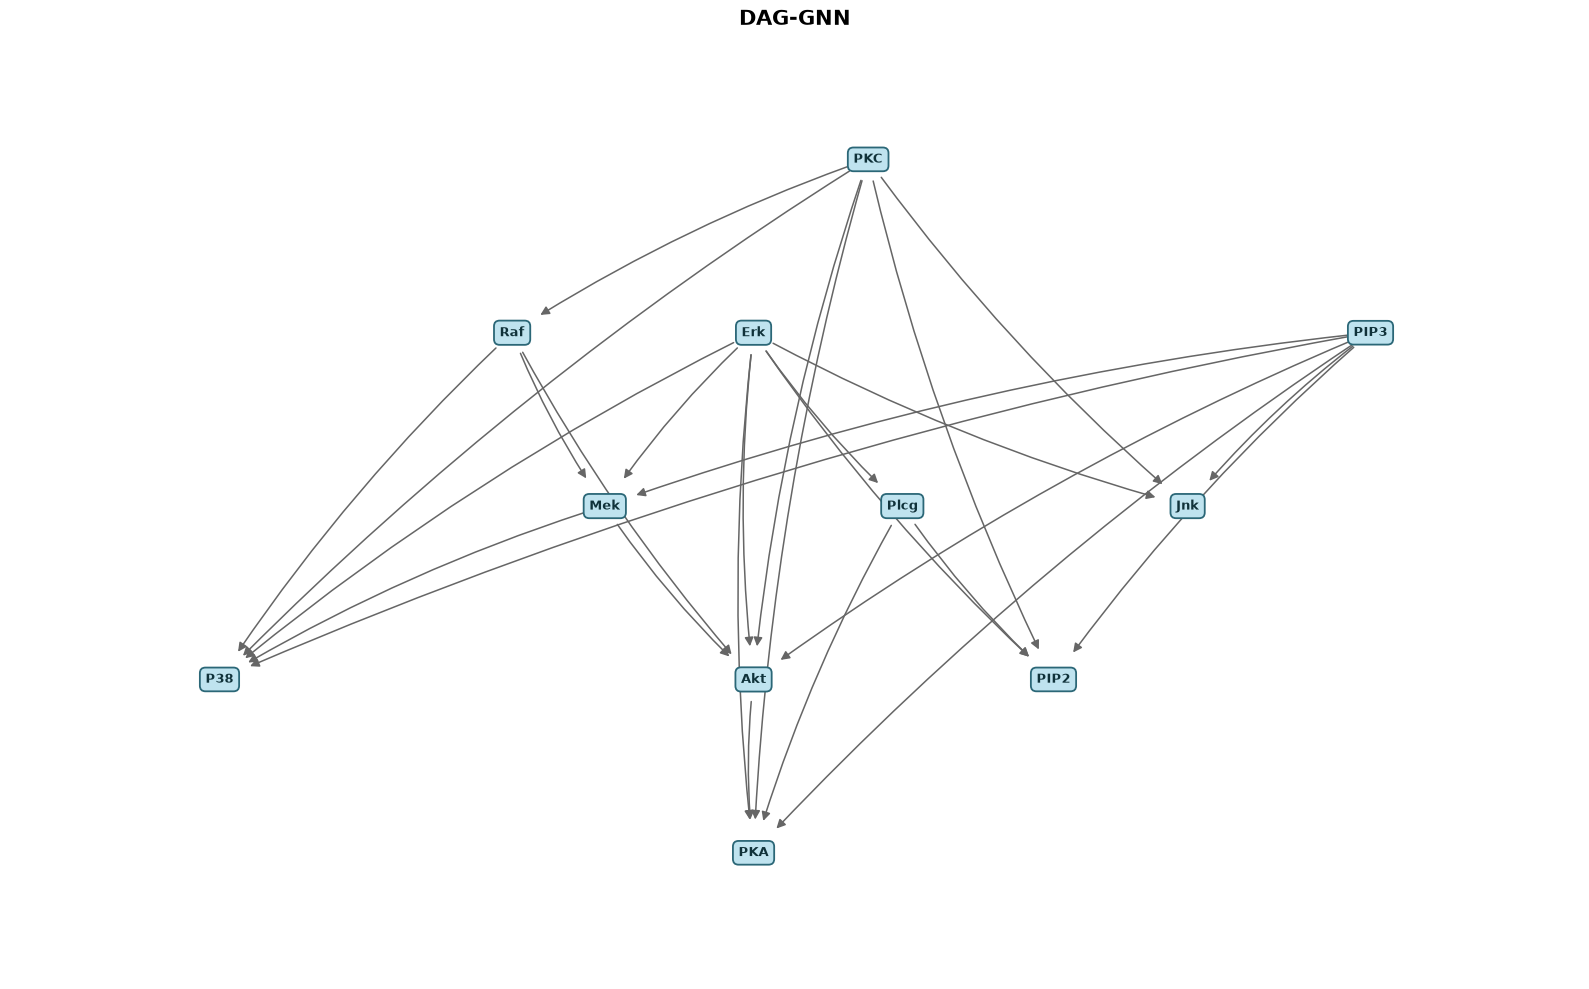

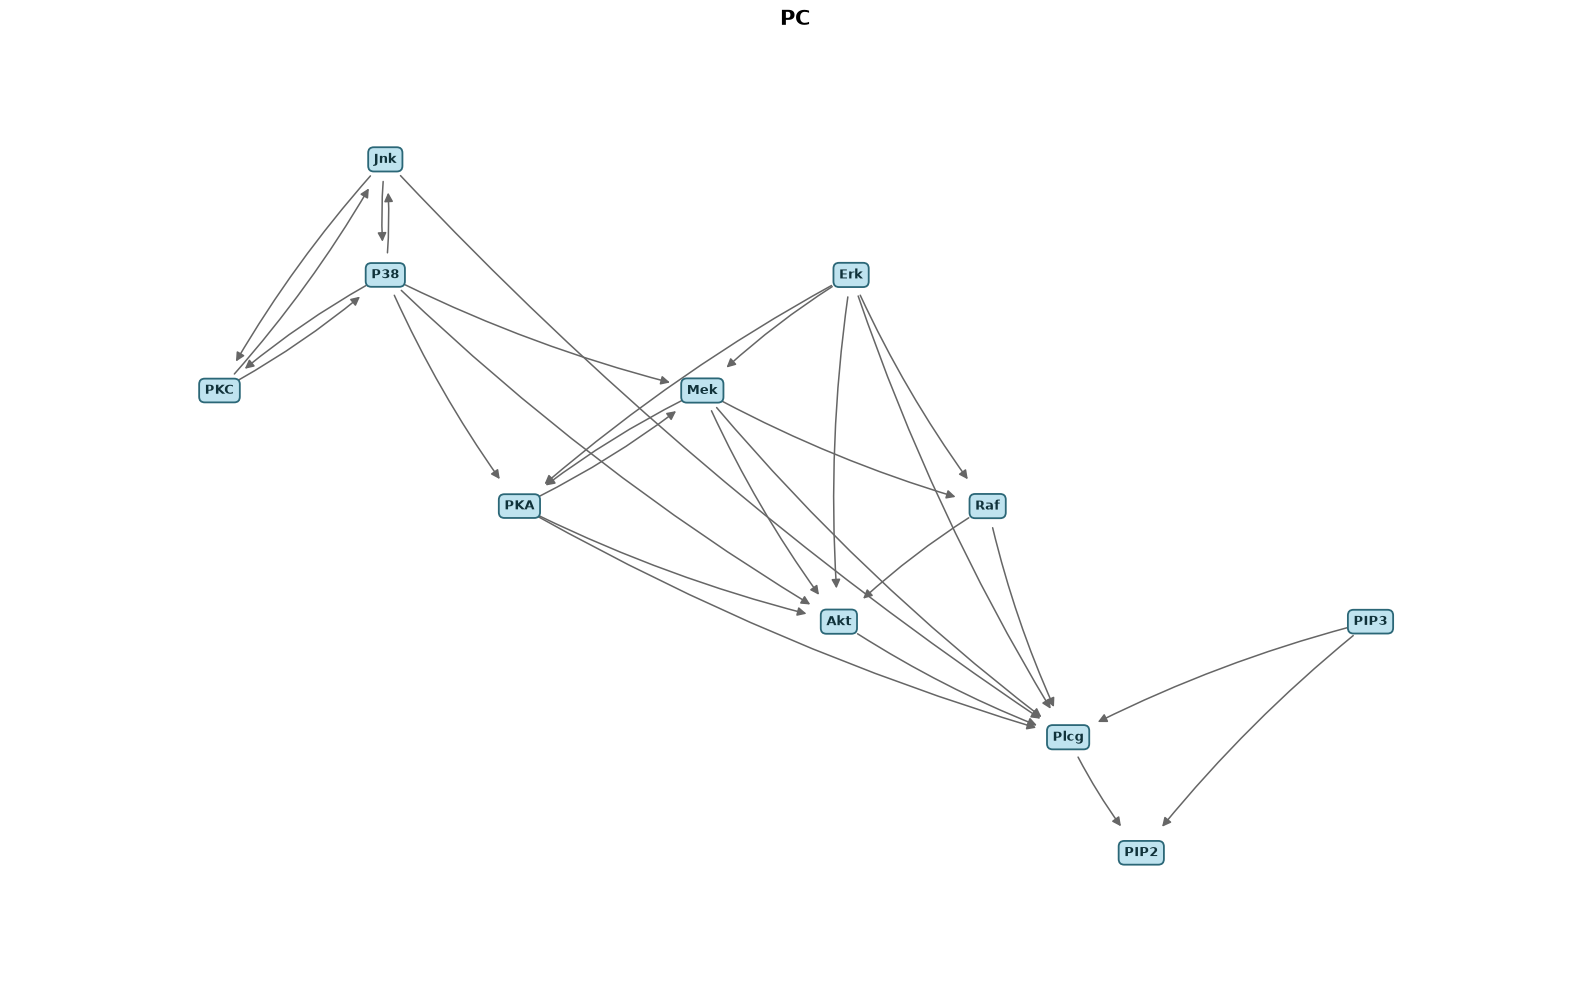

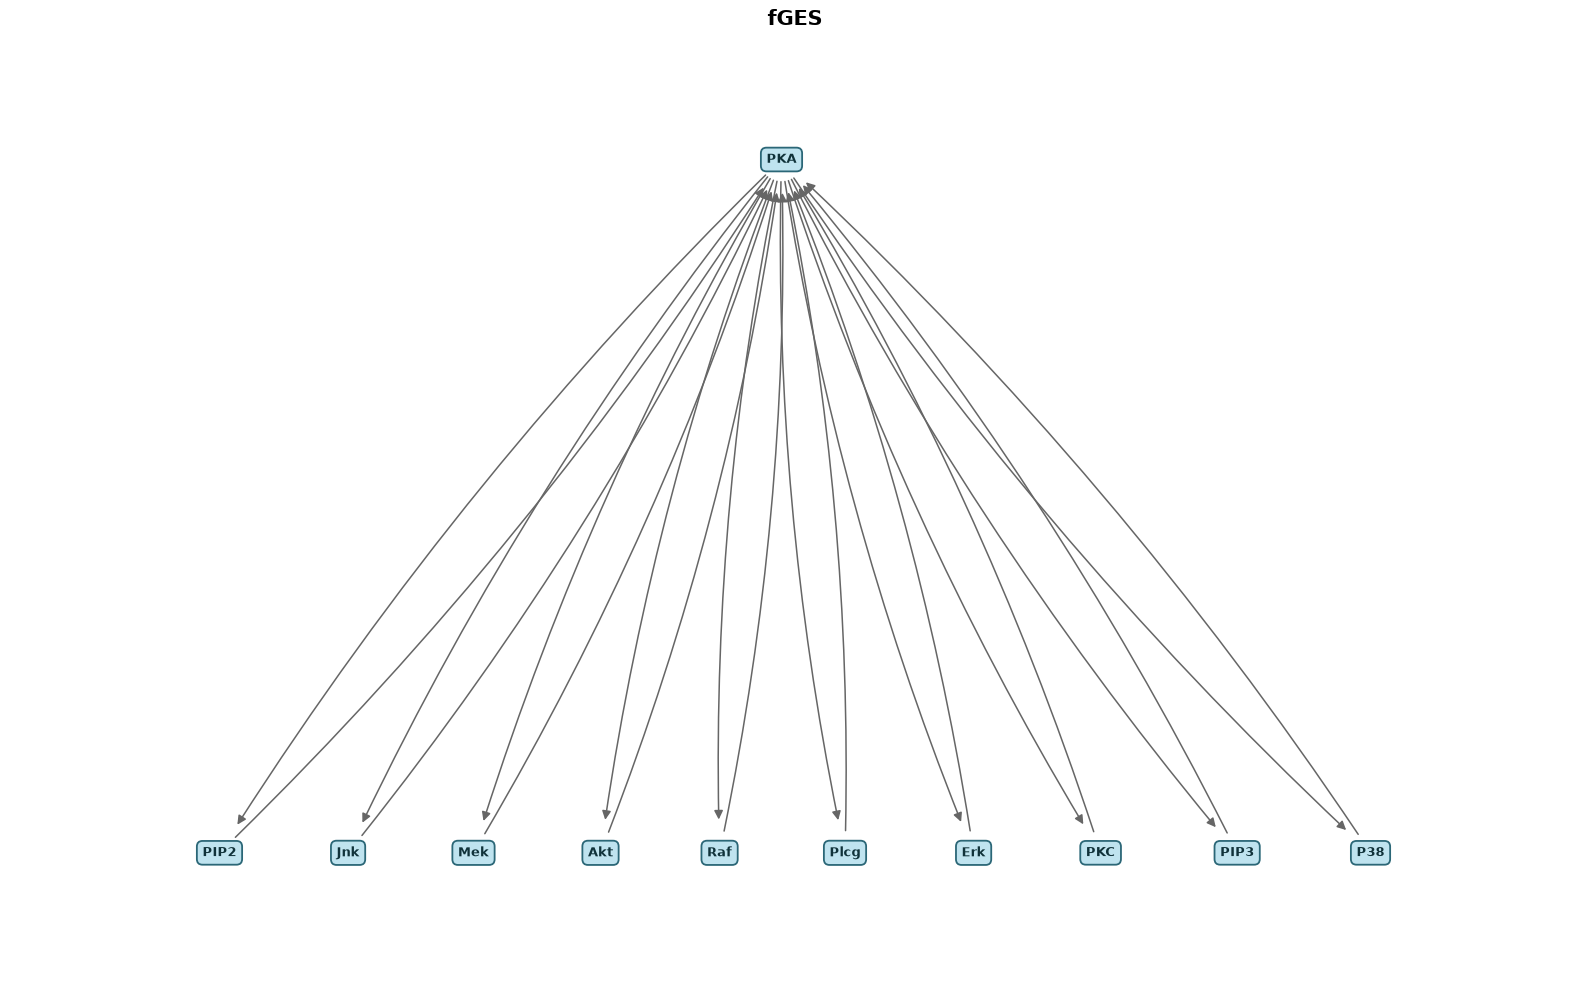

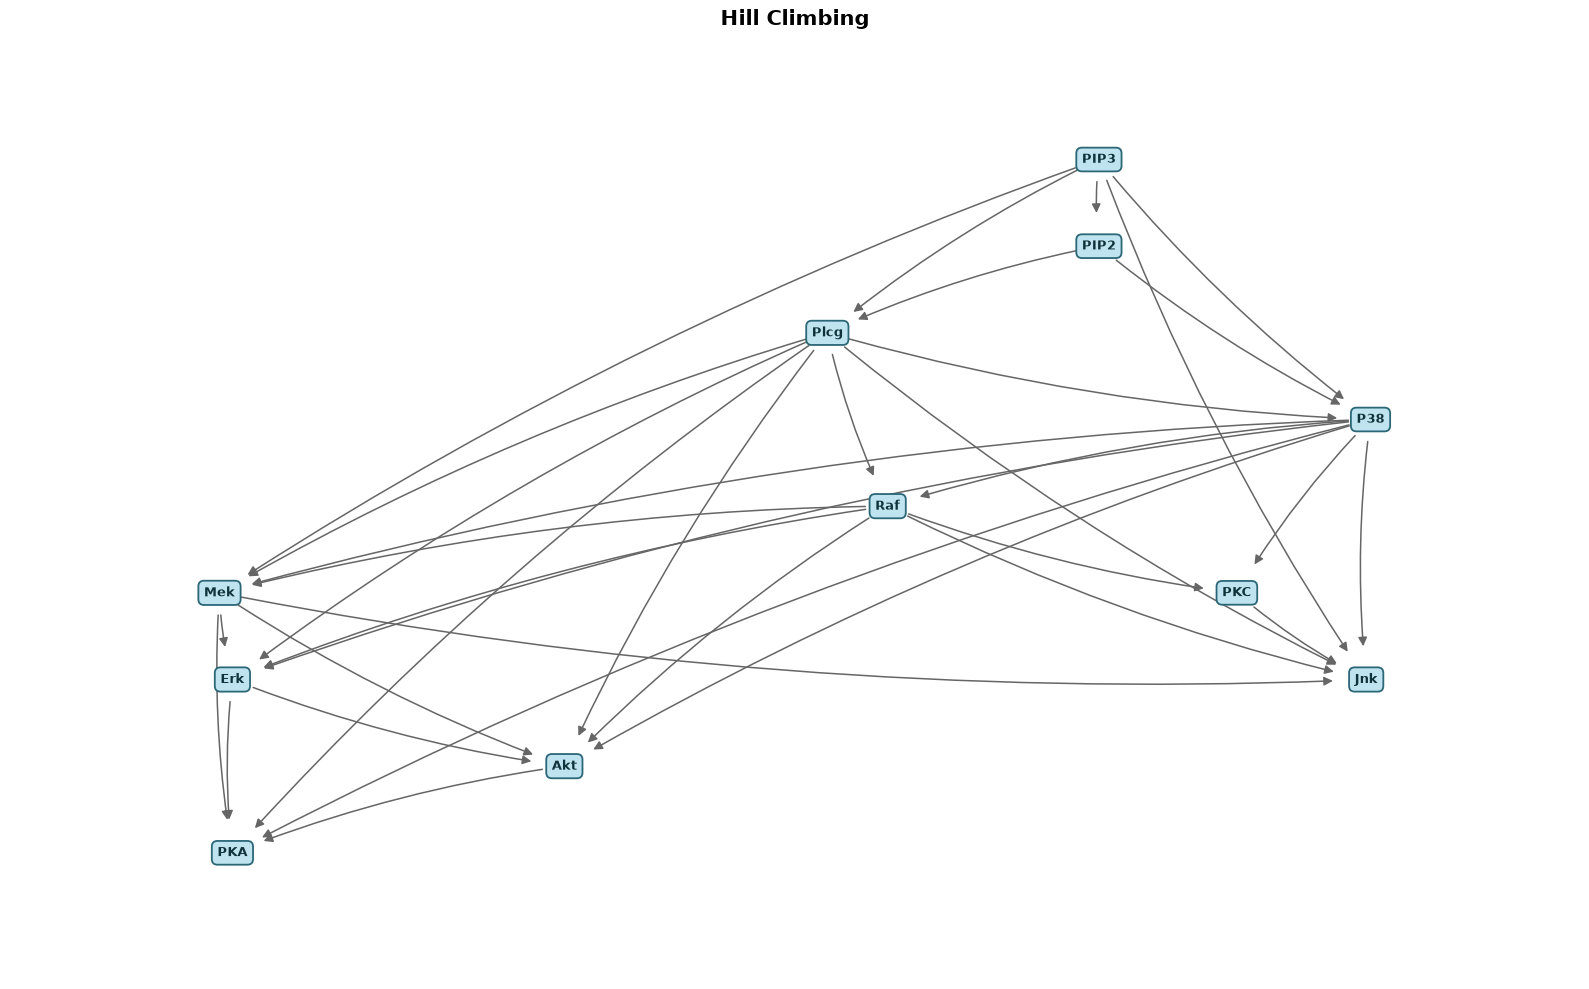

In [37]:
# display of original DAGs and reconstructed ones

plot_dag(sachs_dag, "Sachs et al. original DAG")
plot_dag(sachs_notears_result.edges, "NOTEARS")
plot_dag(sachs_daggnn_result.edges, "DAG-GNN")
plot_dag(sachs_pc_result.edges, "PC")
plot_dag(sachs_fges_result.edges, "fGES")
plot_dag(sachs_hc_result.edges, "Hill Climbing")

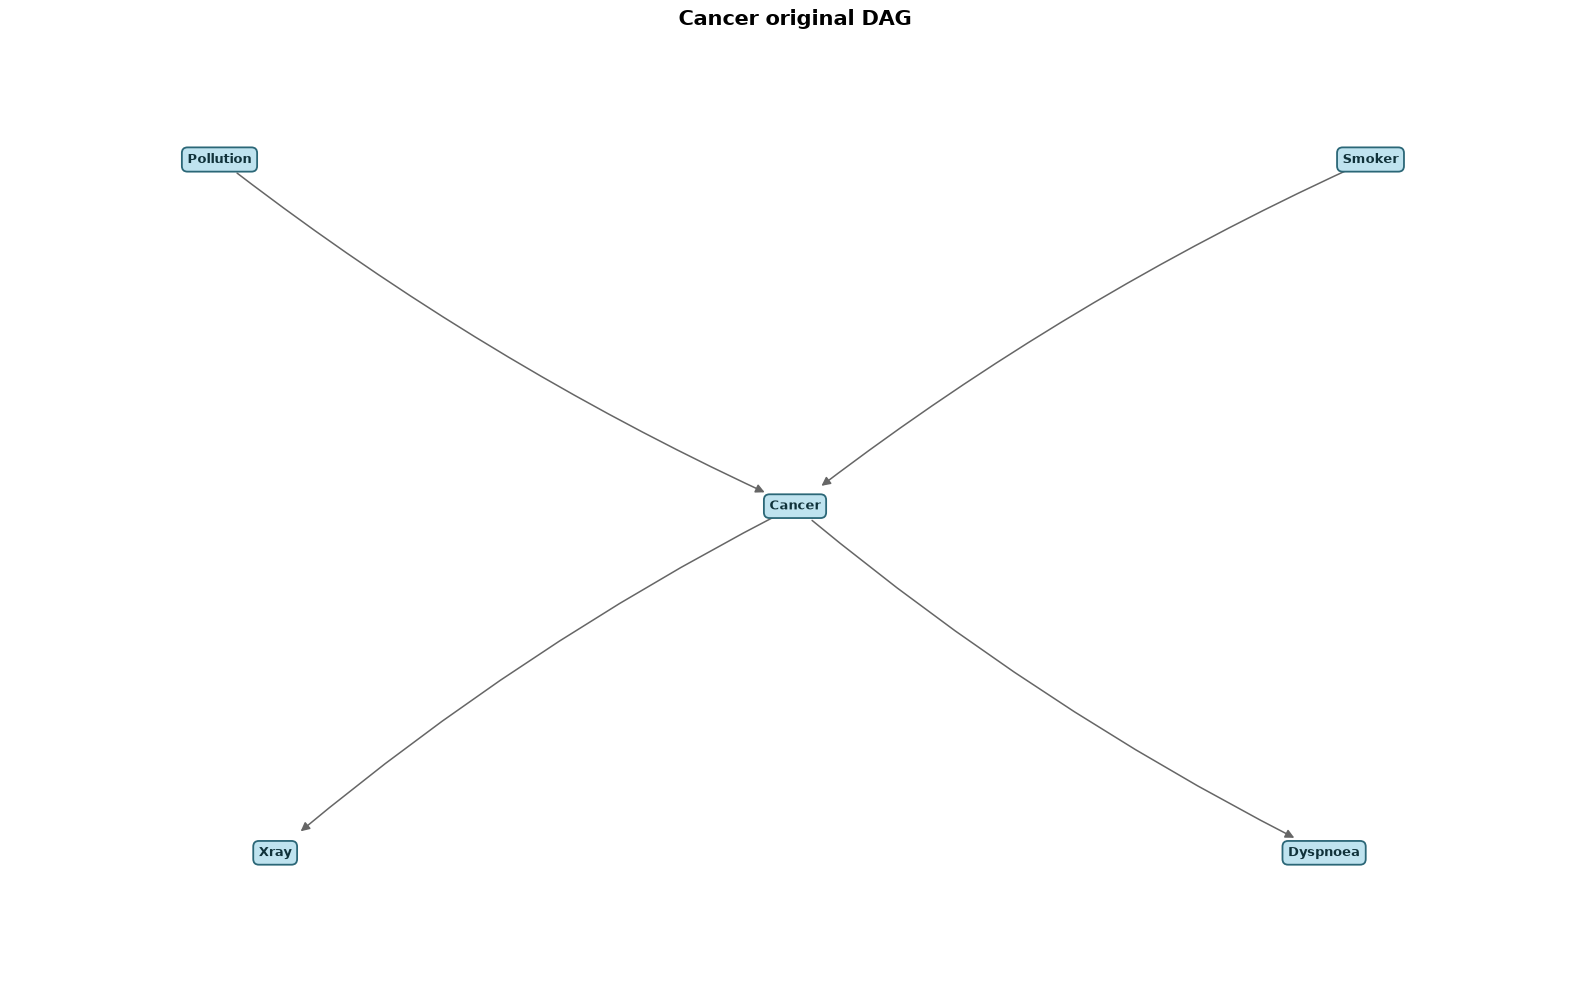

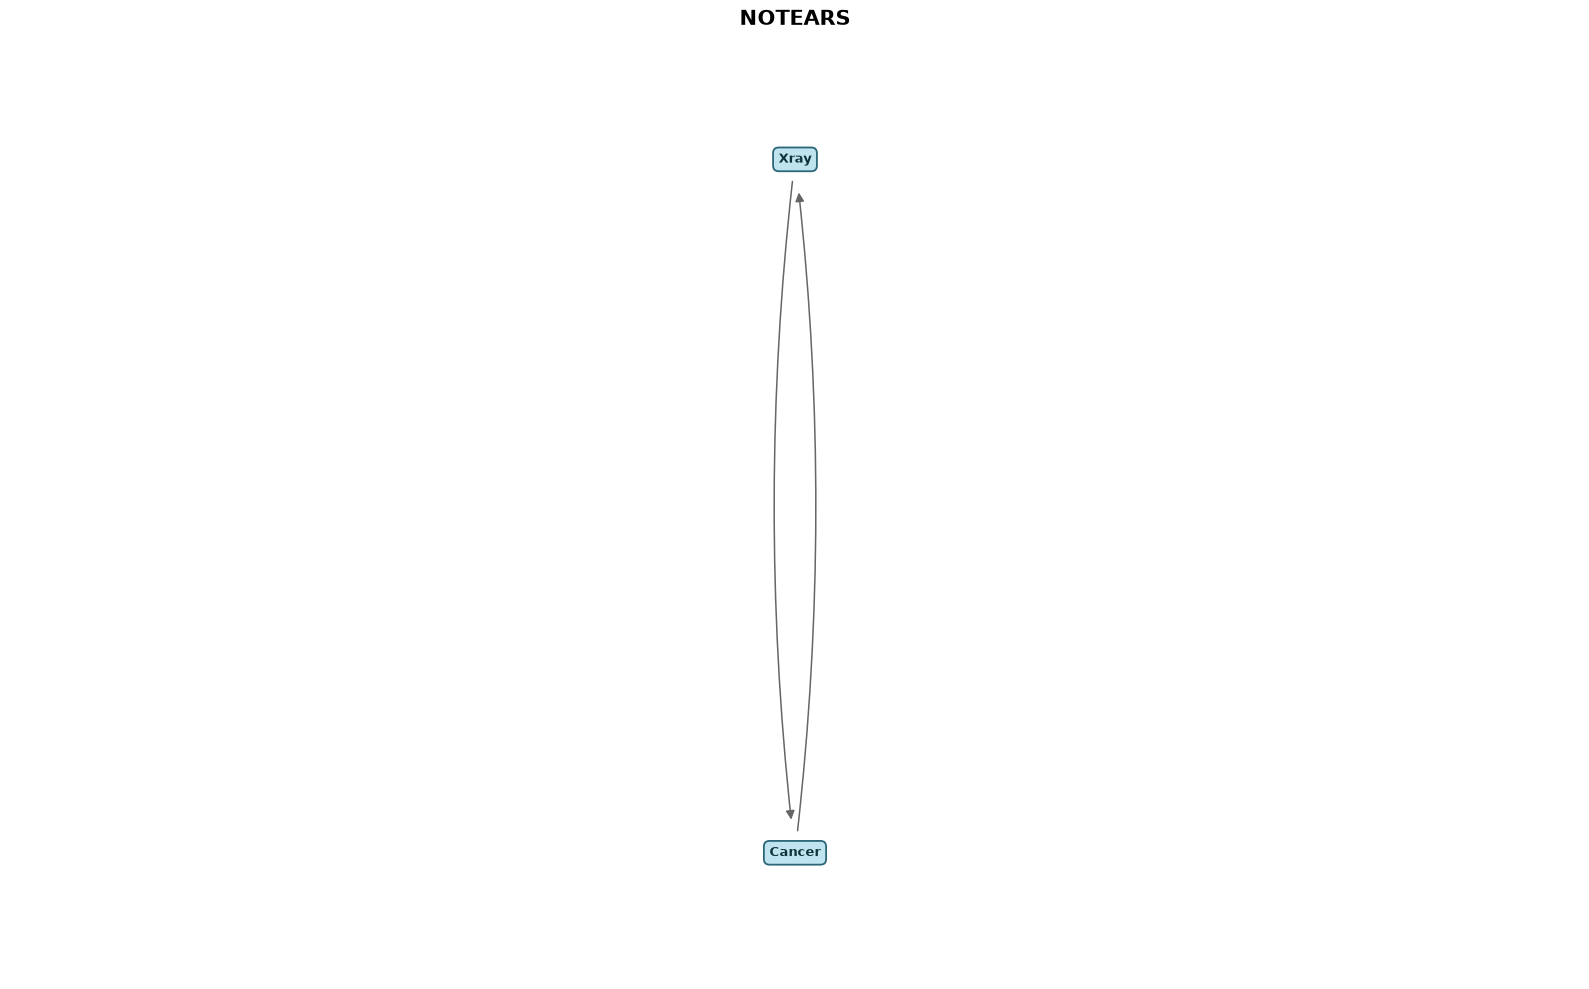

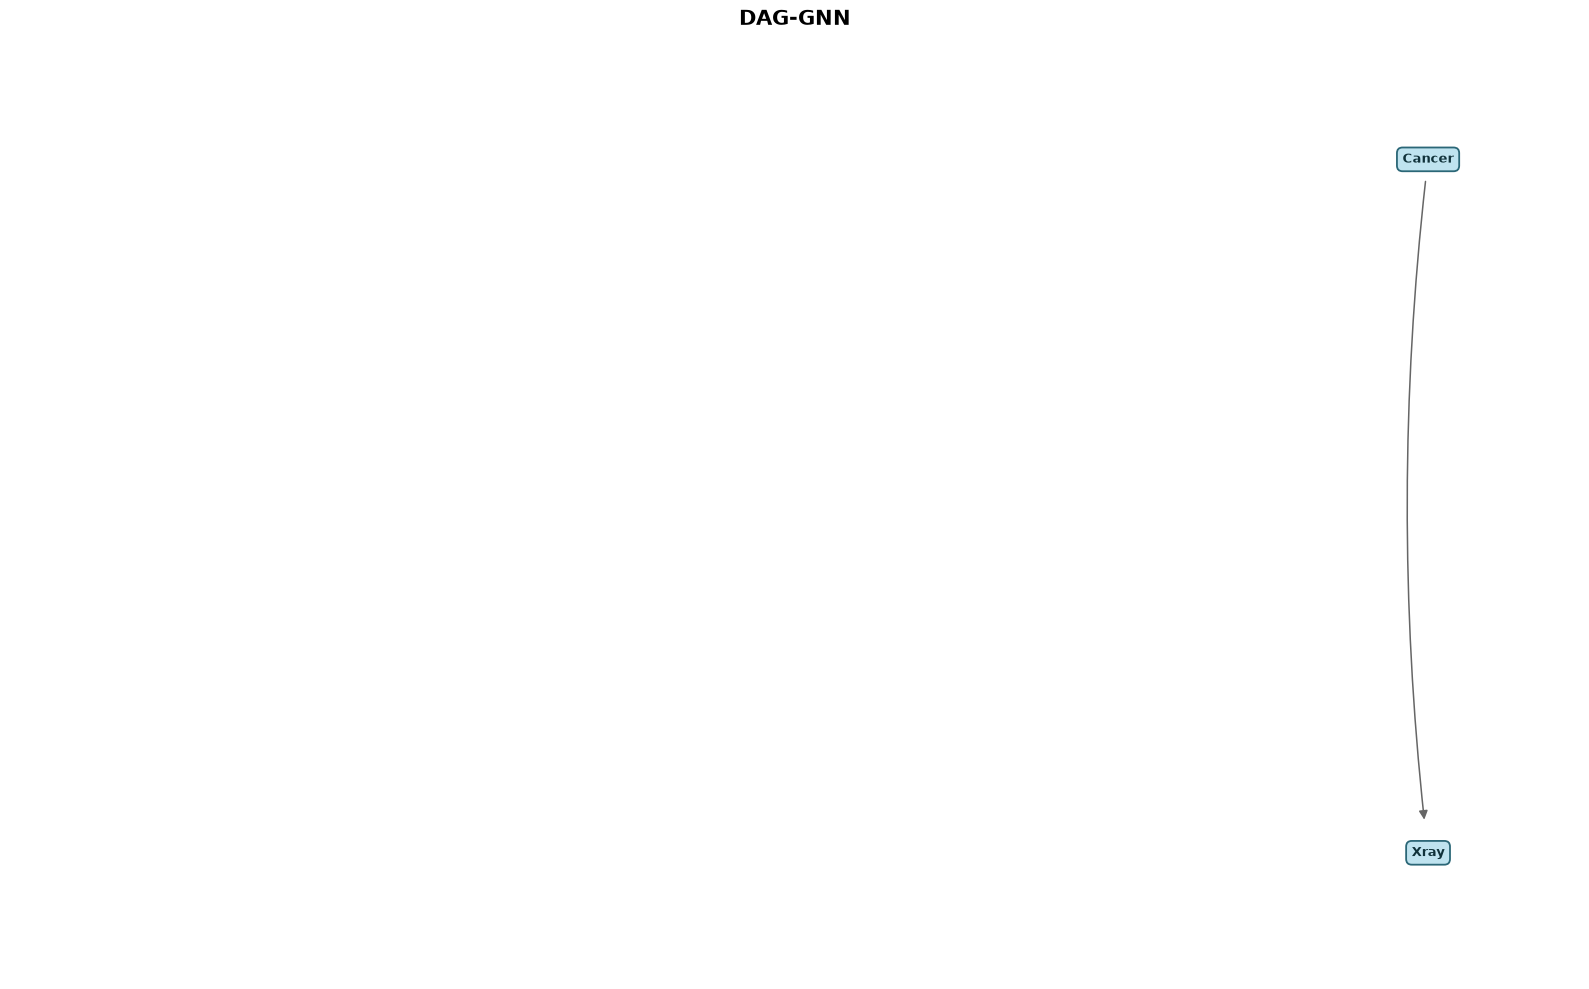

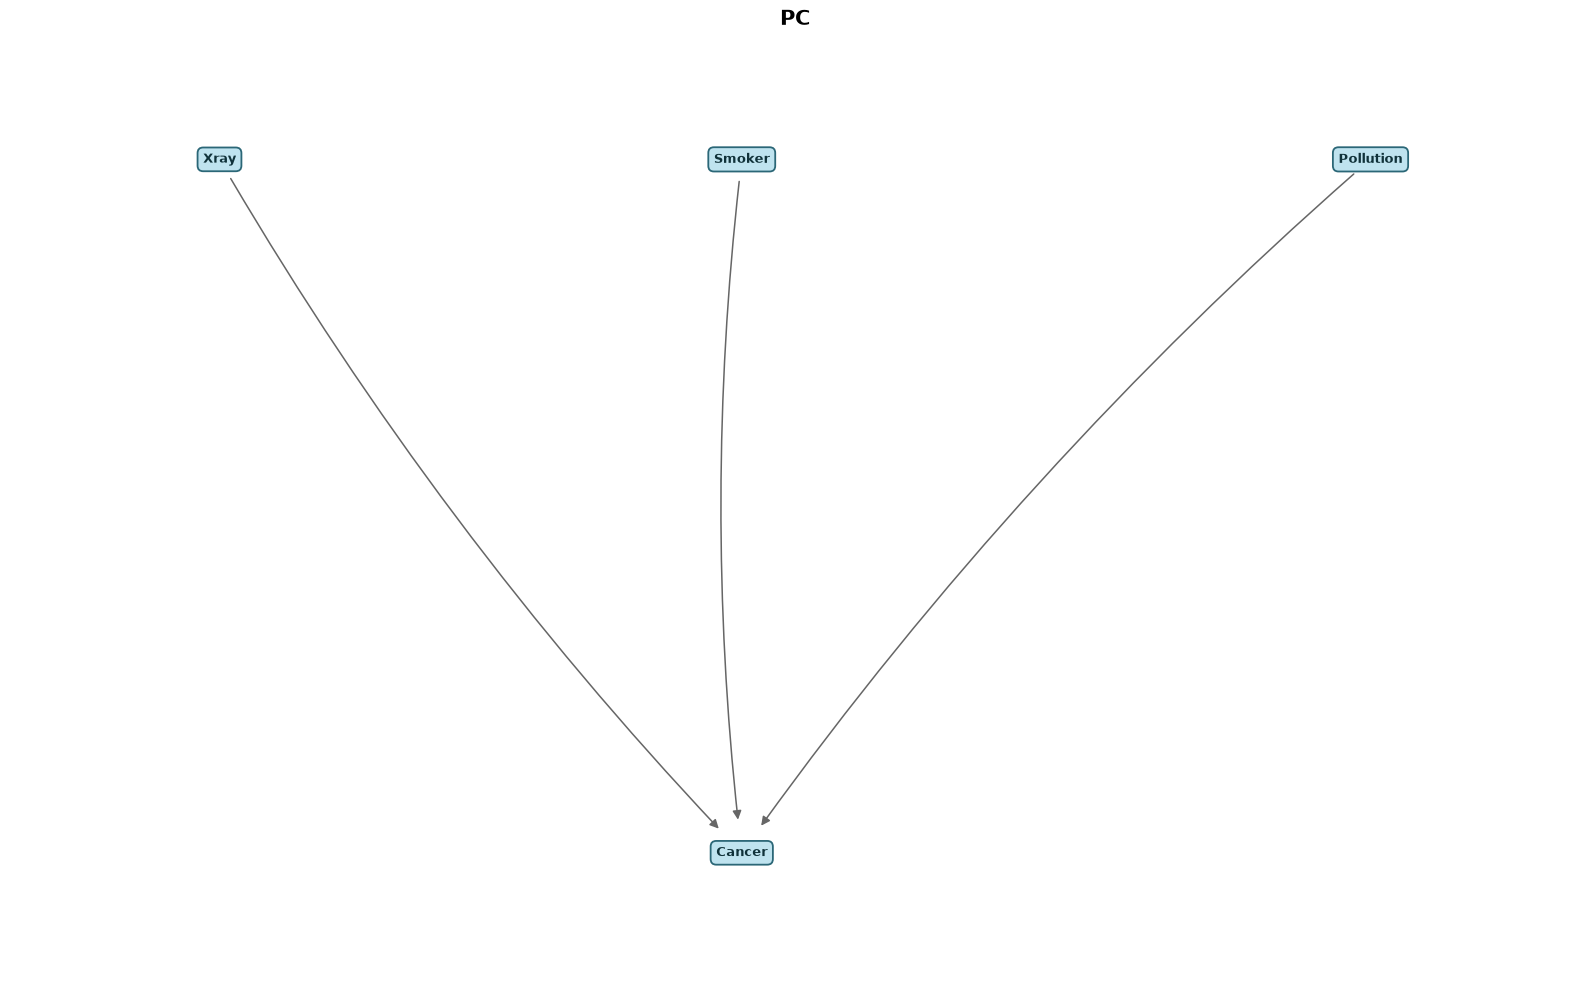

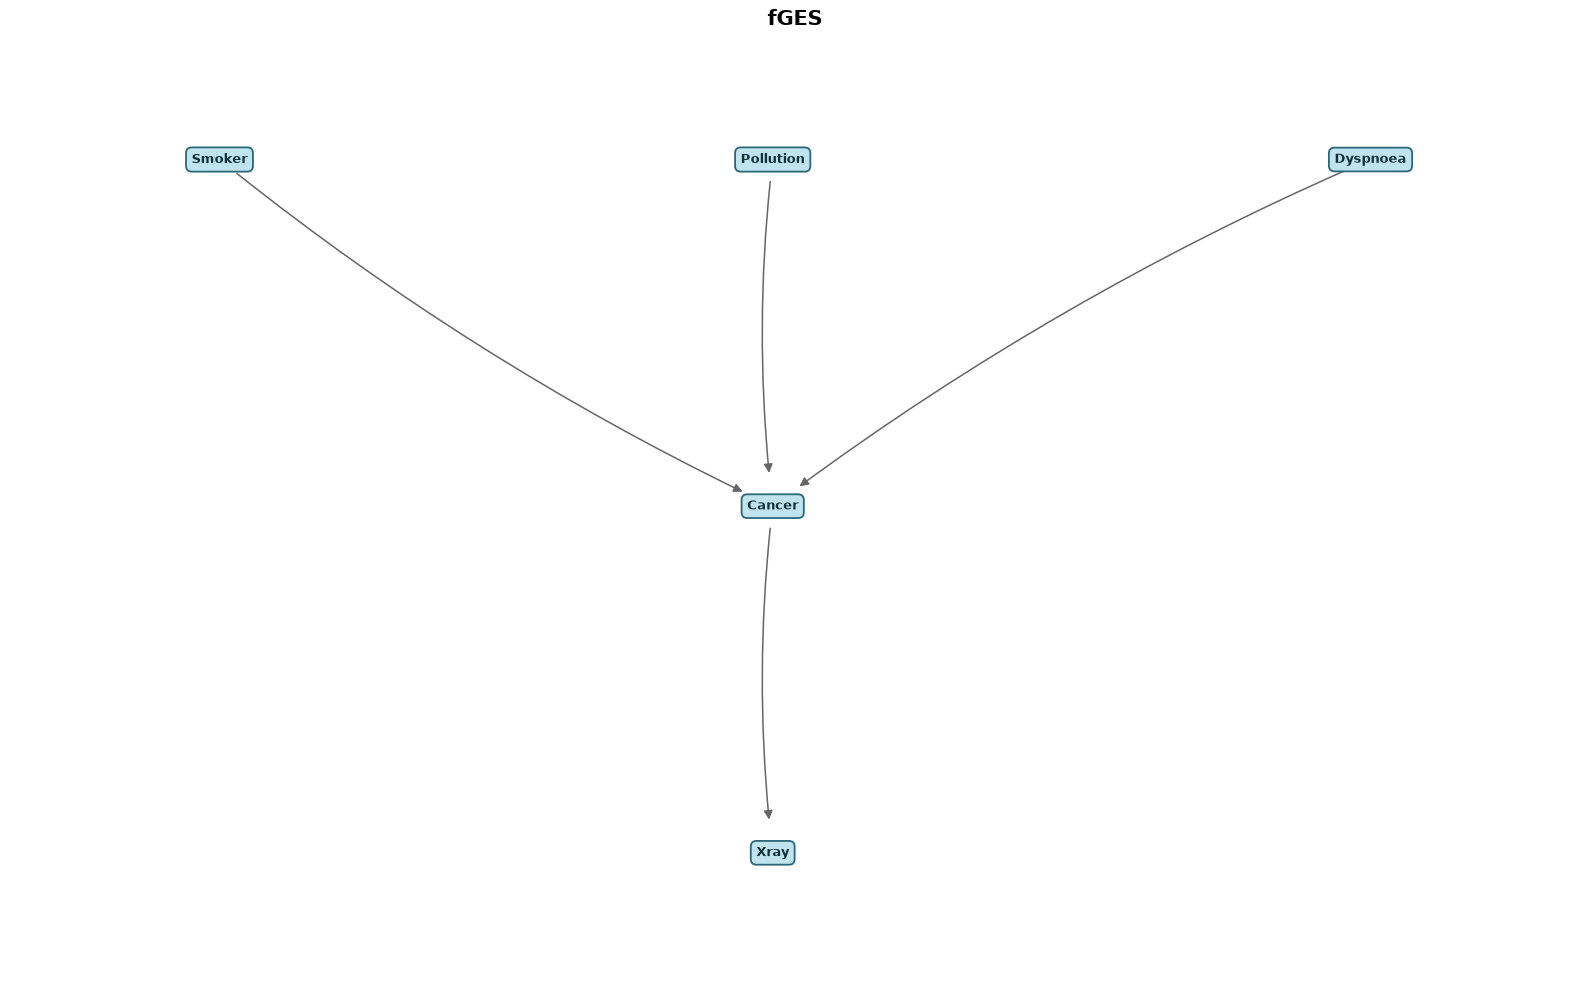

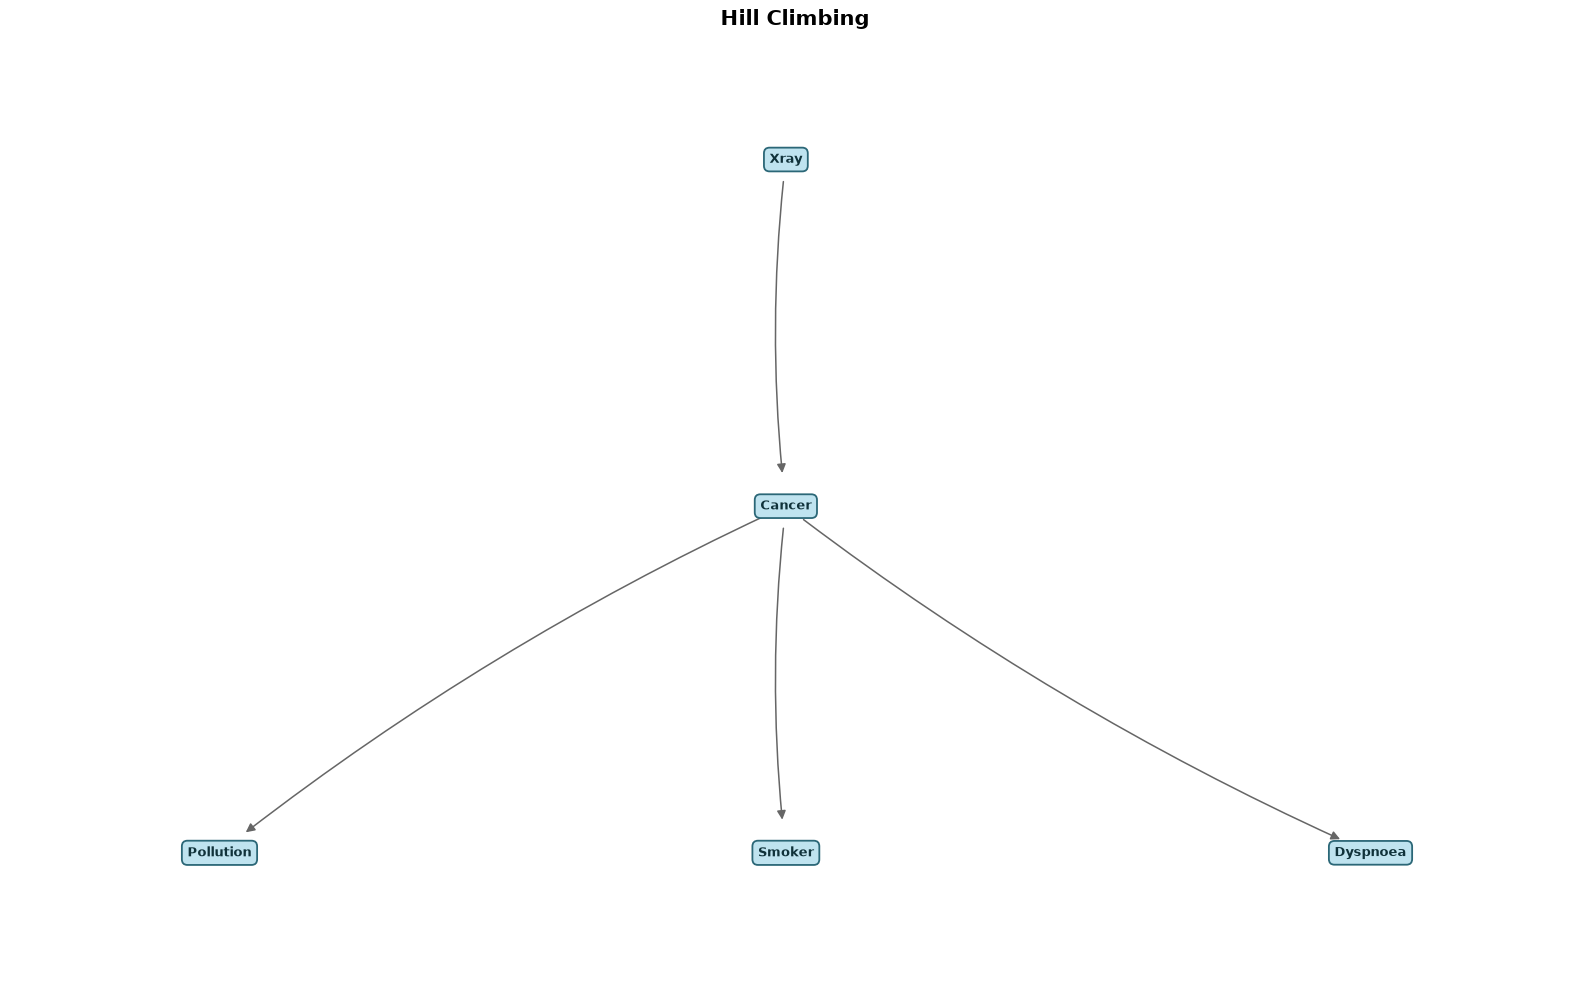

In [38]:
plot_dag(cancer_dag, "Cancer original DAG")
plot_dag(cancer_notears_result.edges, "NOTEARS")
plot_dag(cancer_daggnn_result.edges, "DAG-GNN")
plot_dag(cancer_pc_result.edges, "PC")
plot_dag(cancer_fges_result.edges, "fGES")
plot_dag(cancer_hc_result.edges, "Hill Climbing")

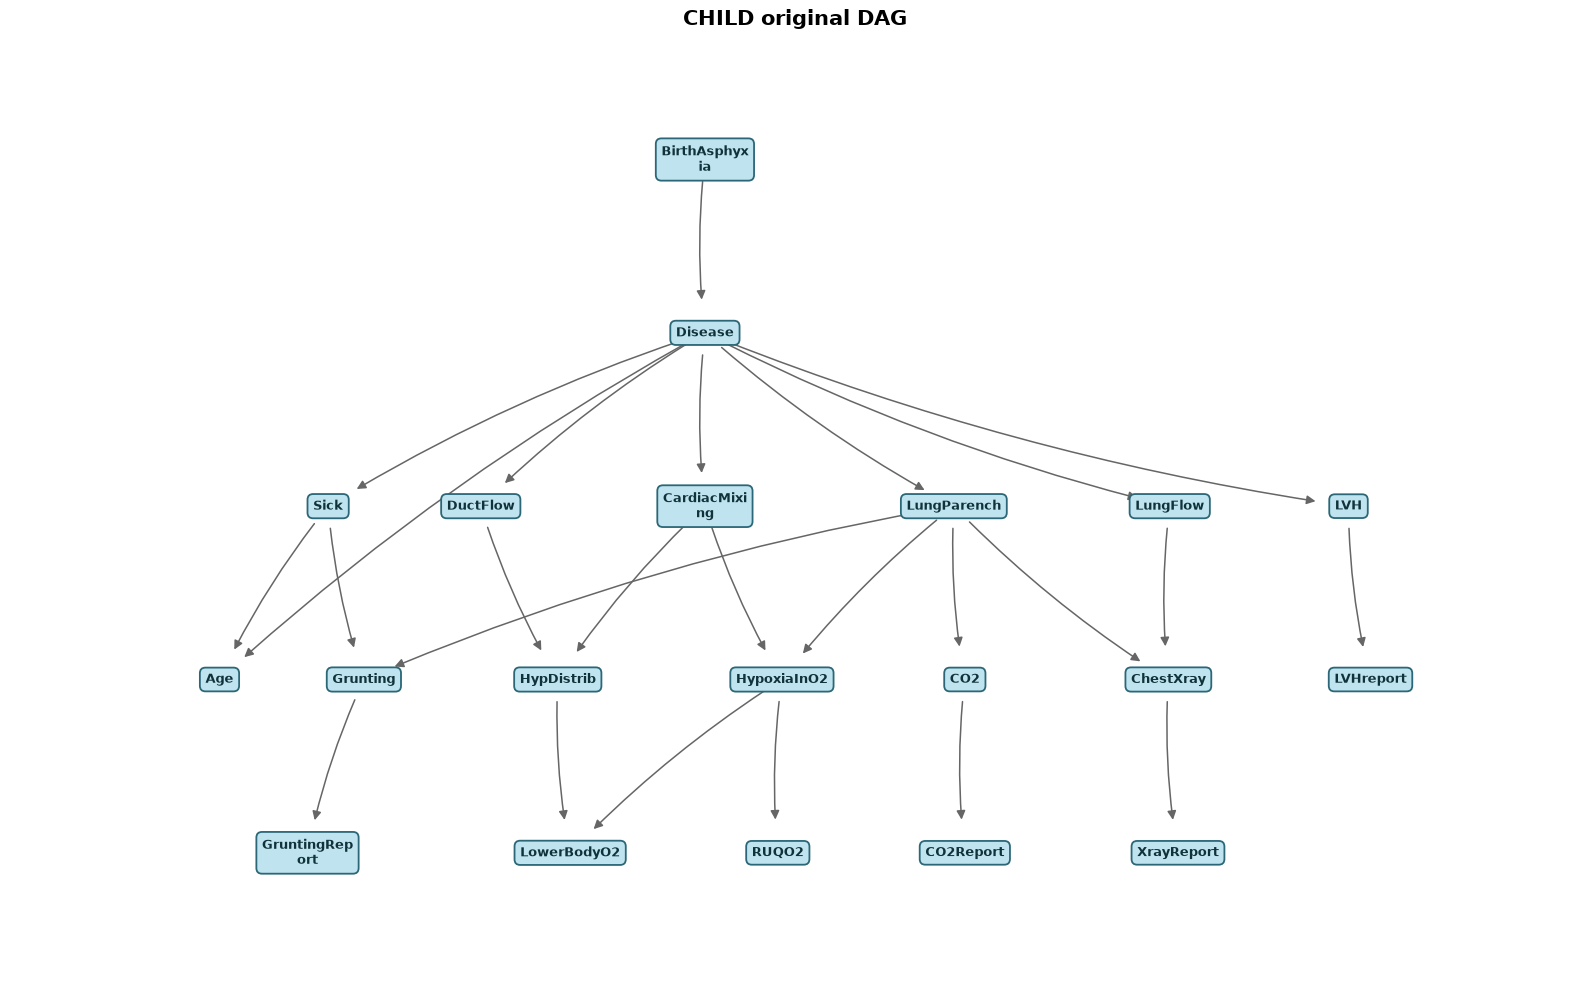

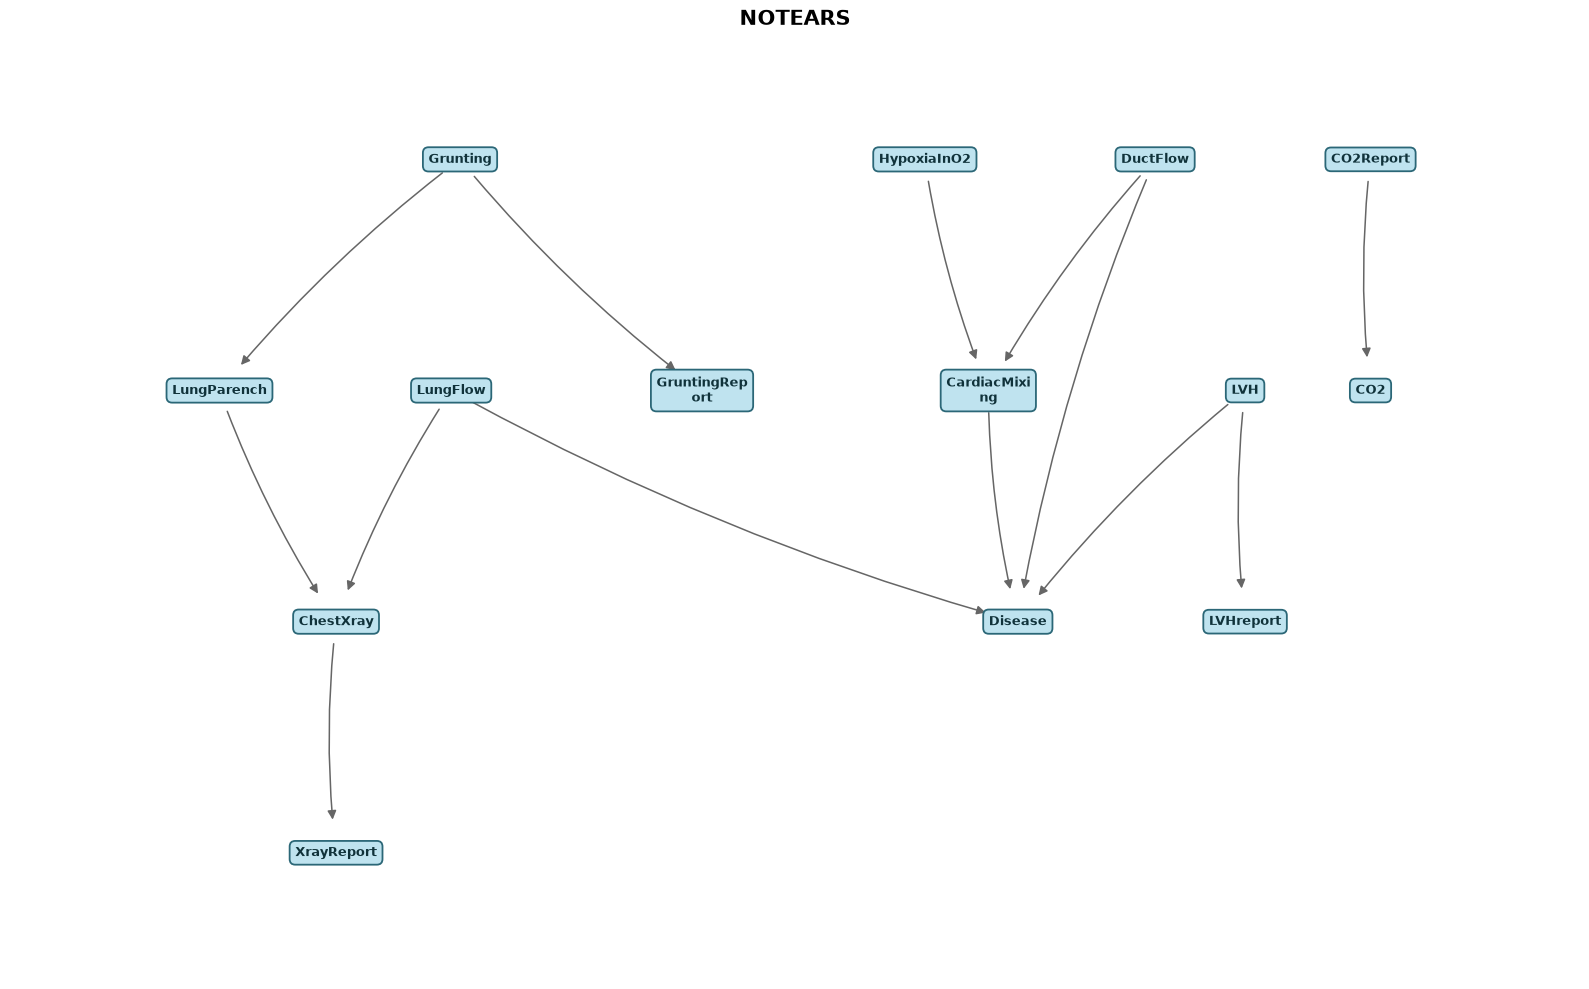

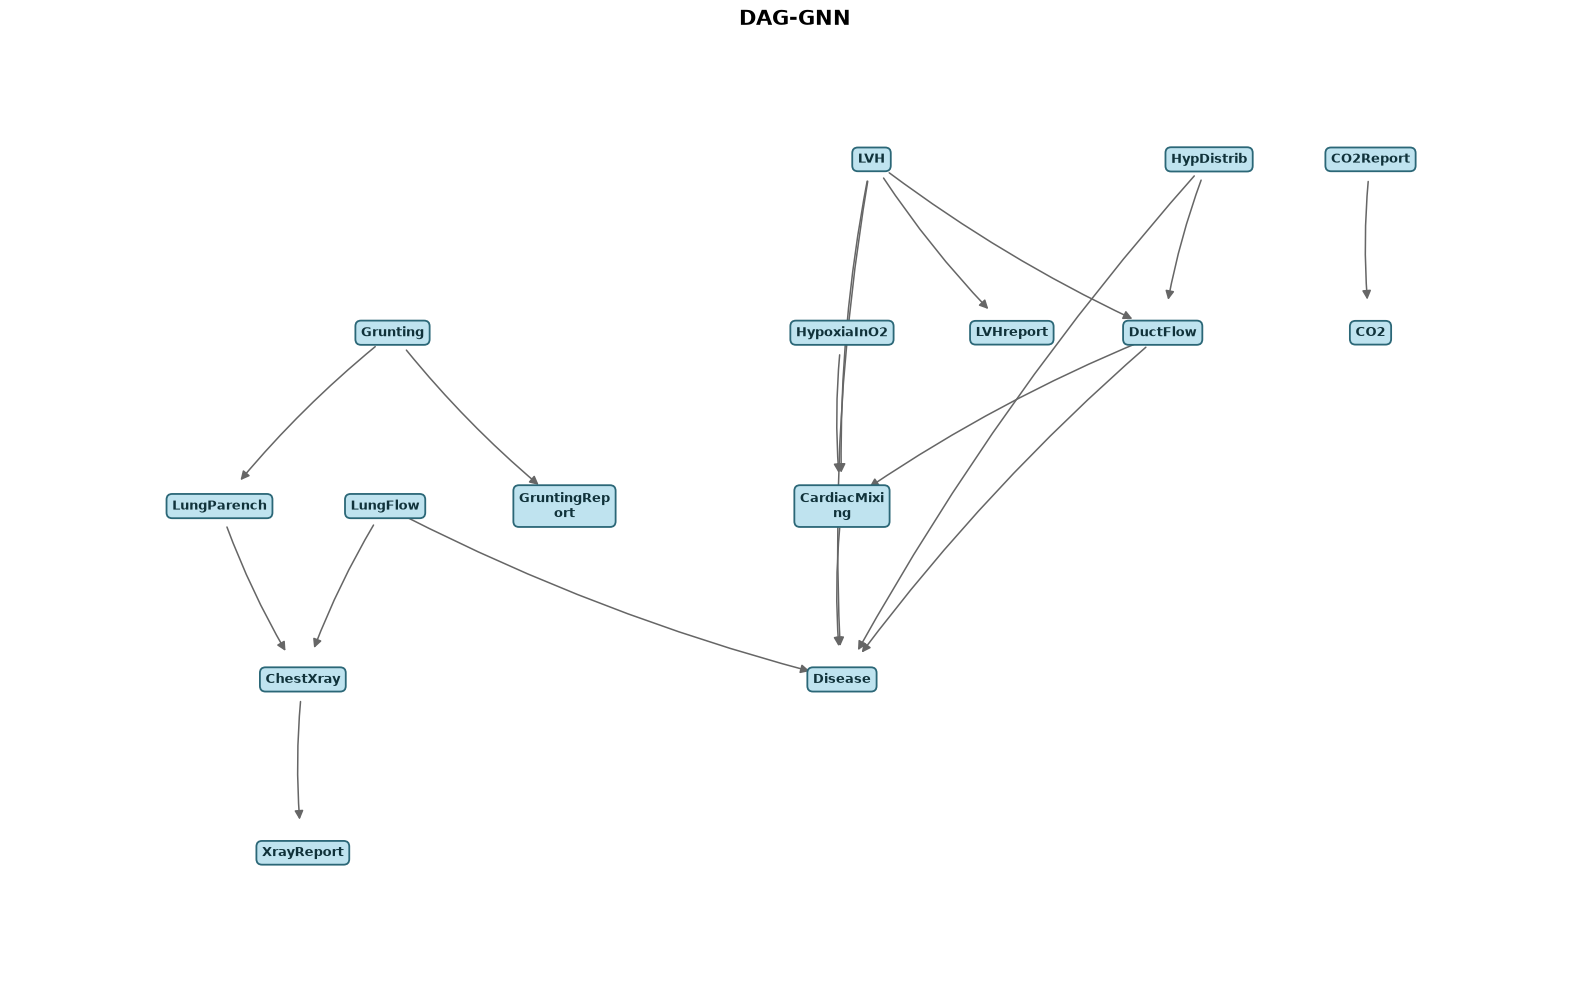

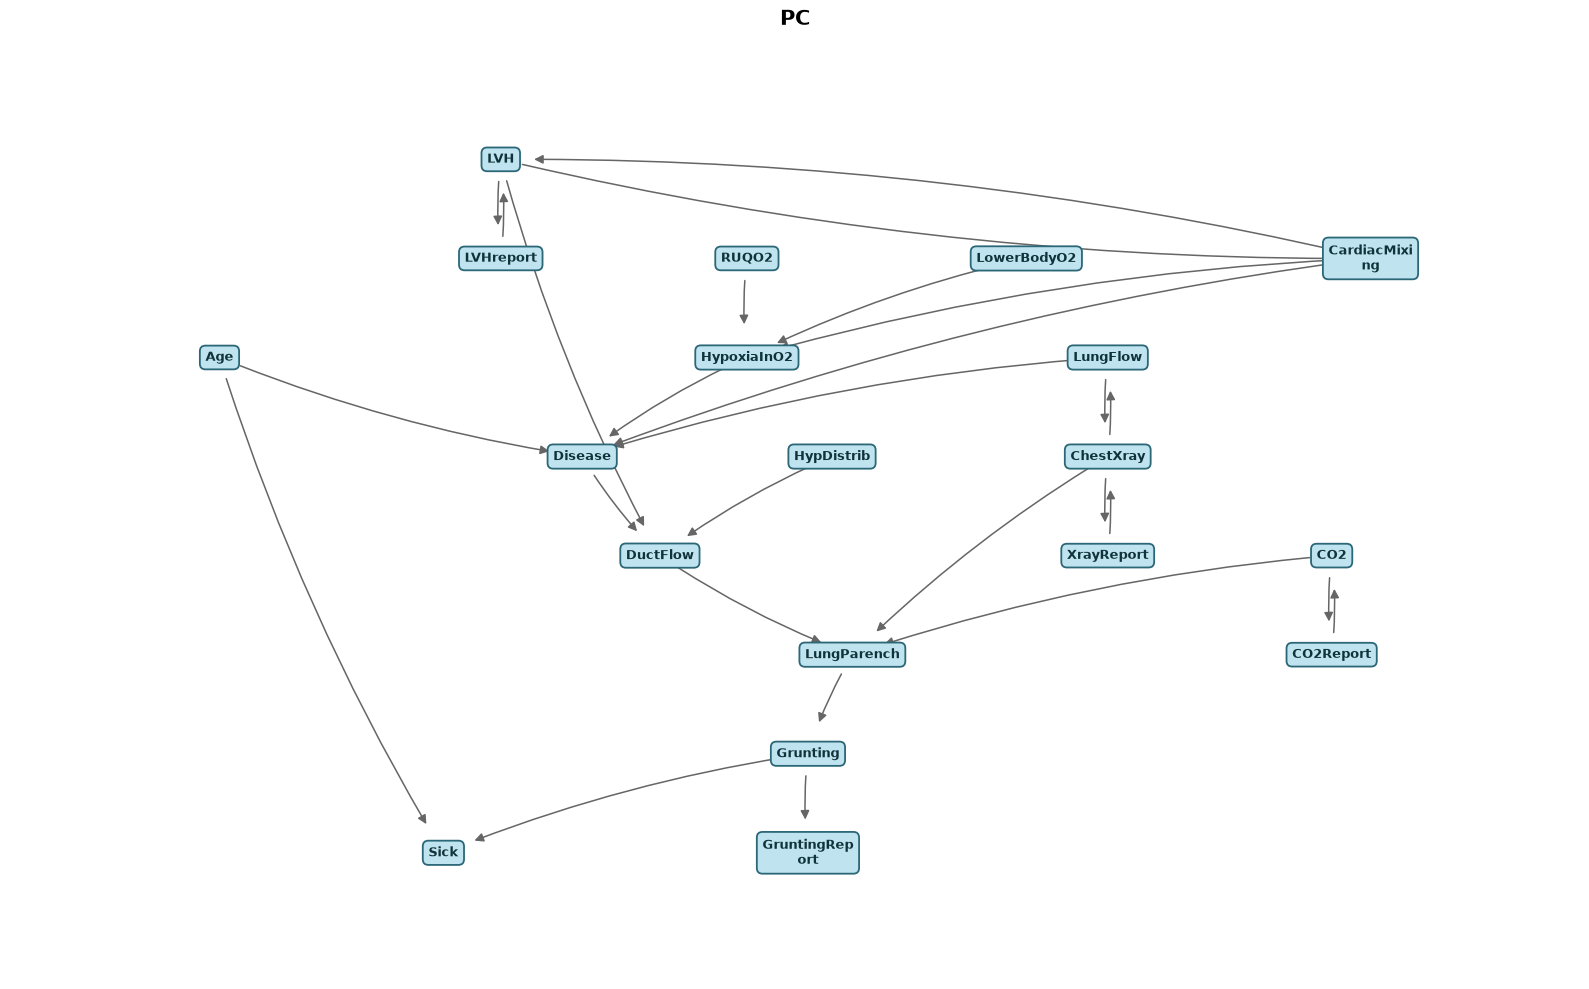

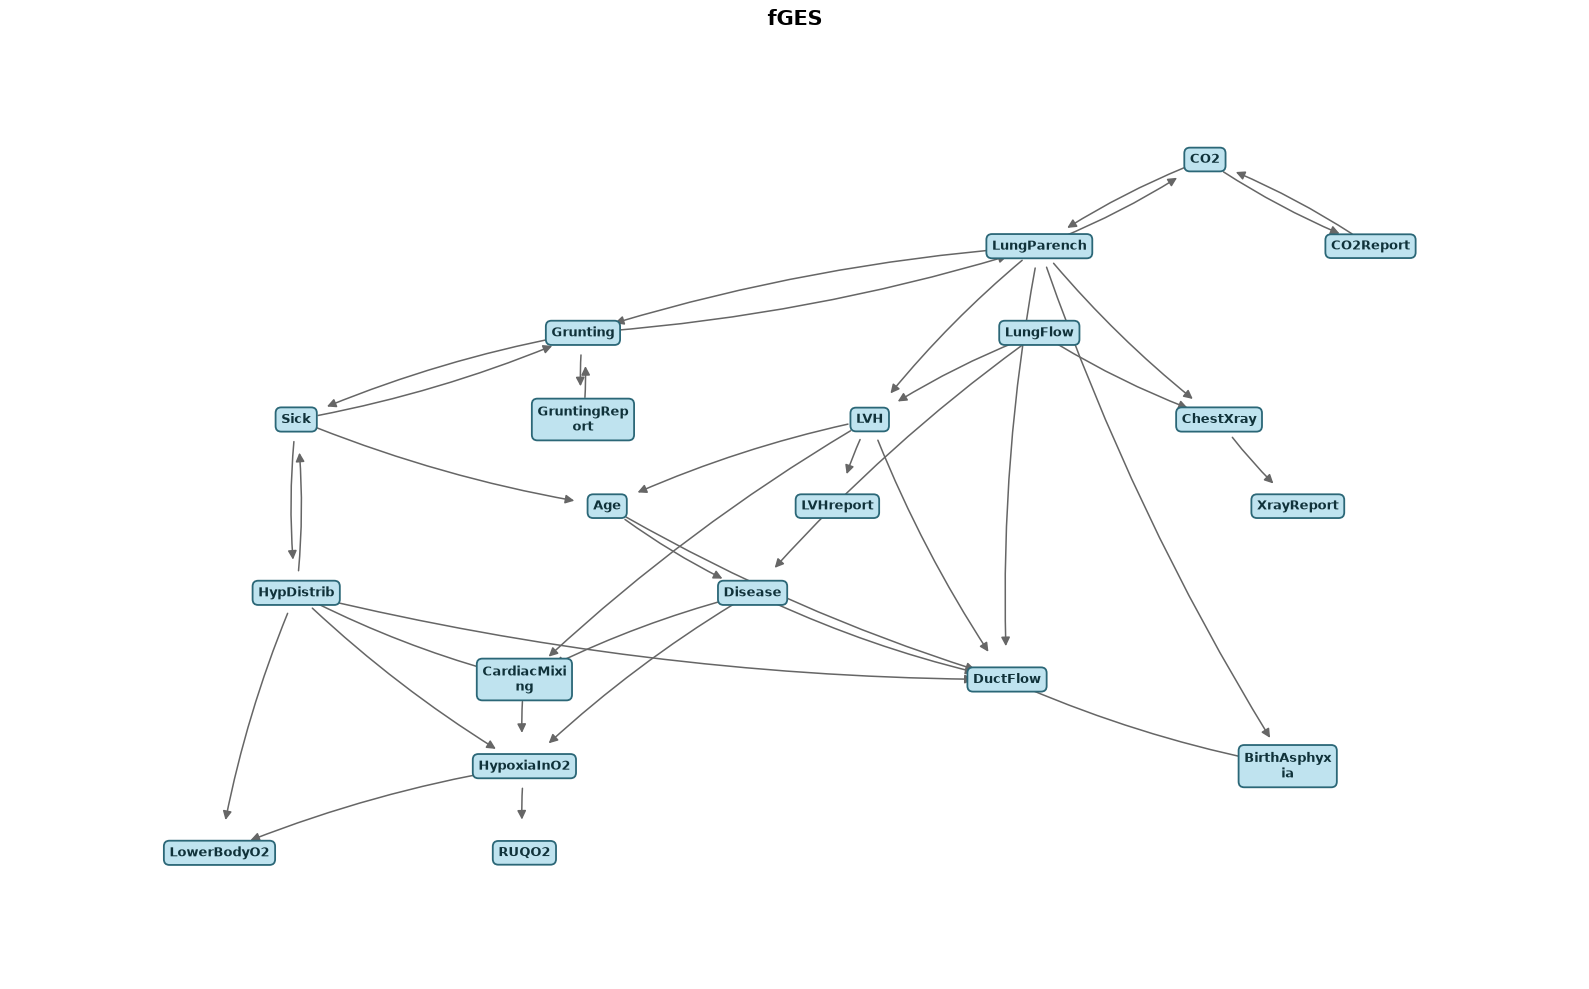

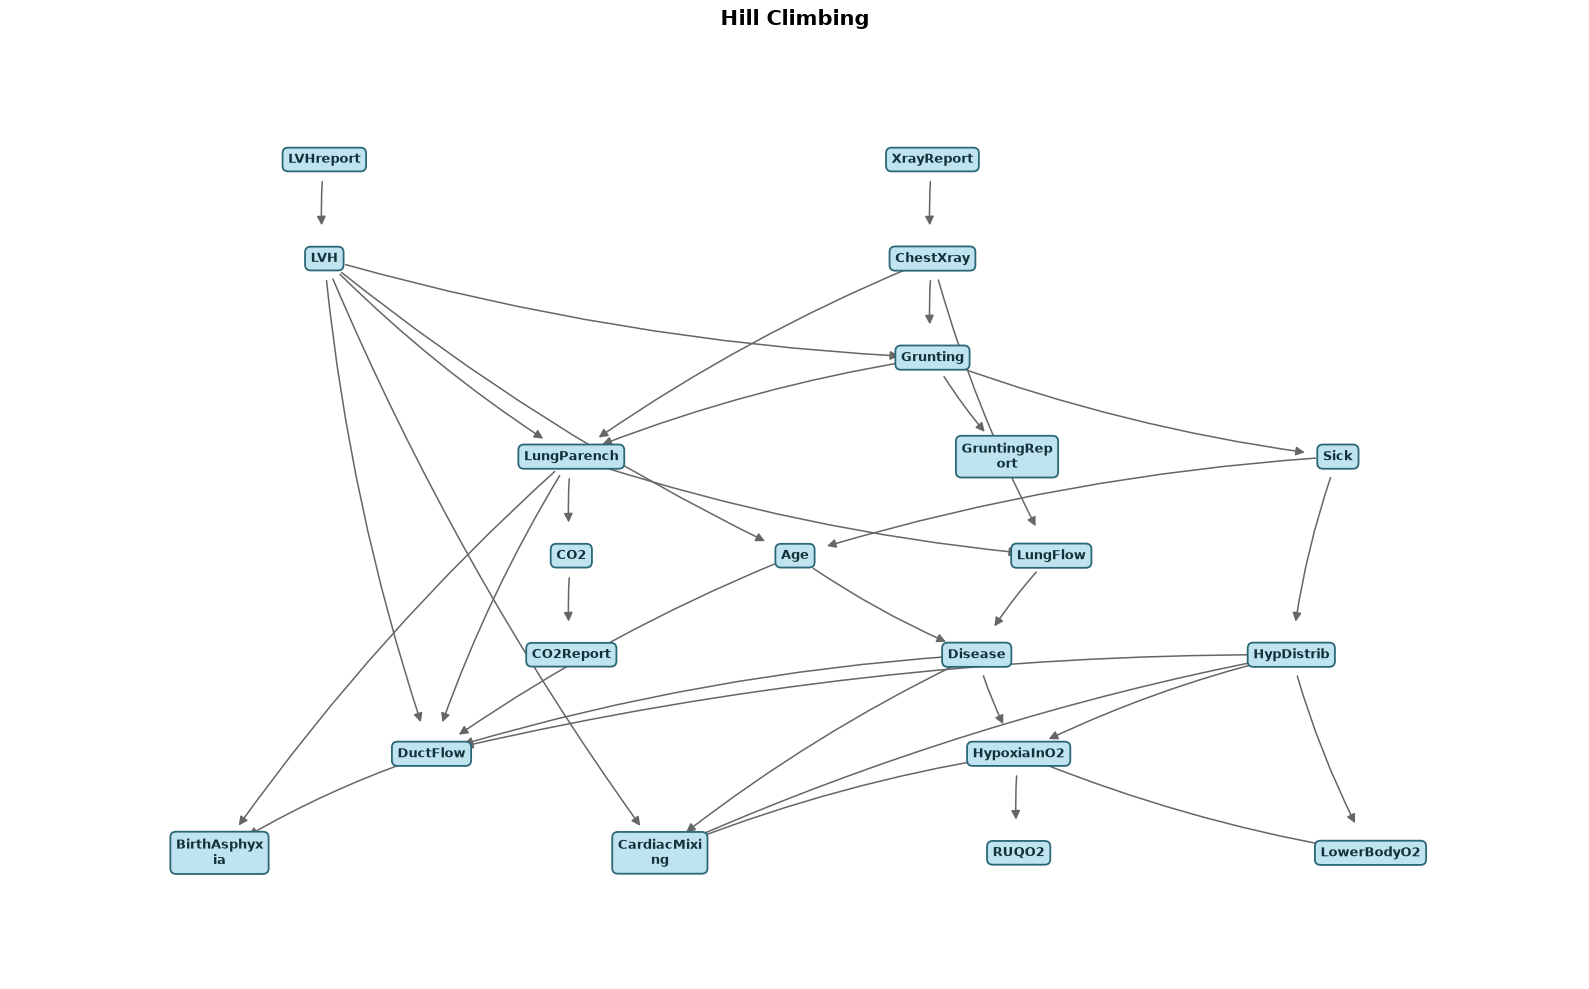

In [39]:
plot_dag(child_dag, "CHILD original DAG")
plot_dag(child_notears_result.edges, "NOTEARS")
plot_dag(child_daggnn_result.edges, "DAG-GNN")
plot_dag(child_pc_result.edges, "PC")
plot_dag(child_fges_result.edges, "fGES")
plot_dag(child_hc_result.edges, "Hill Climbing")

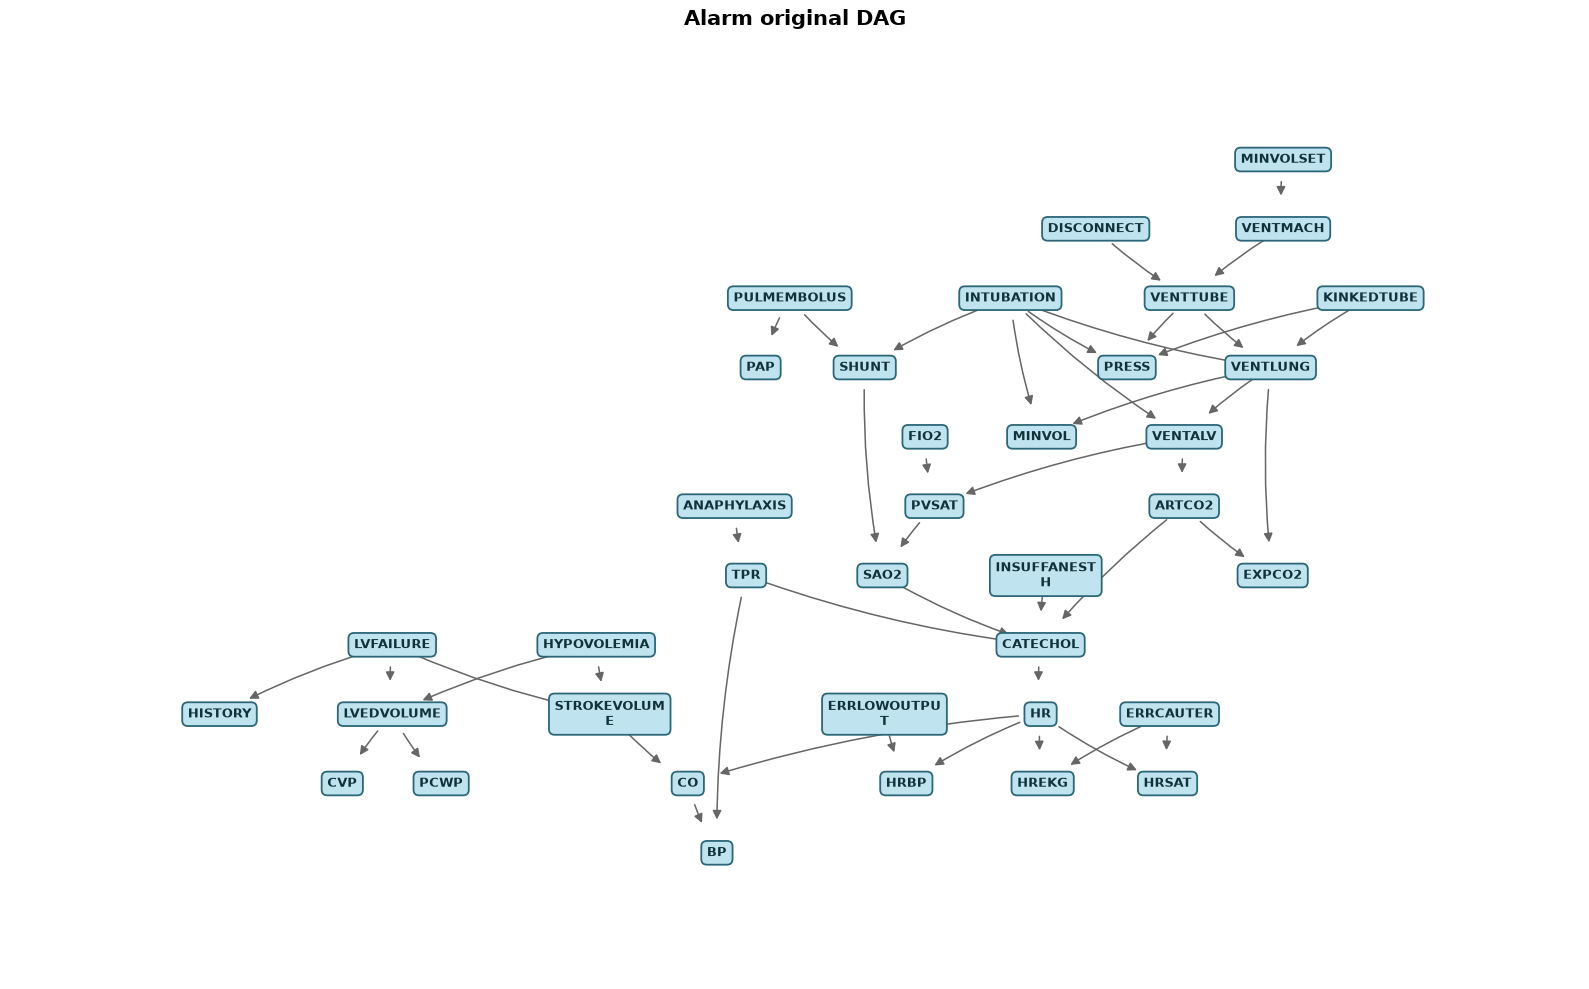

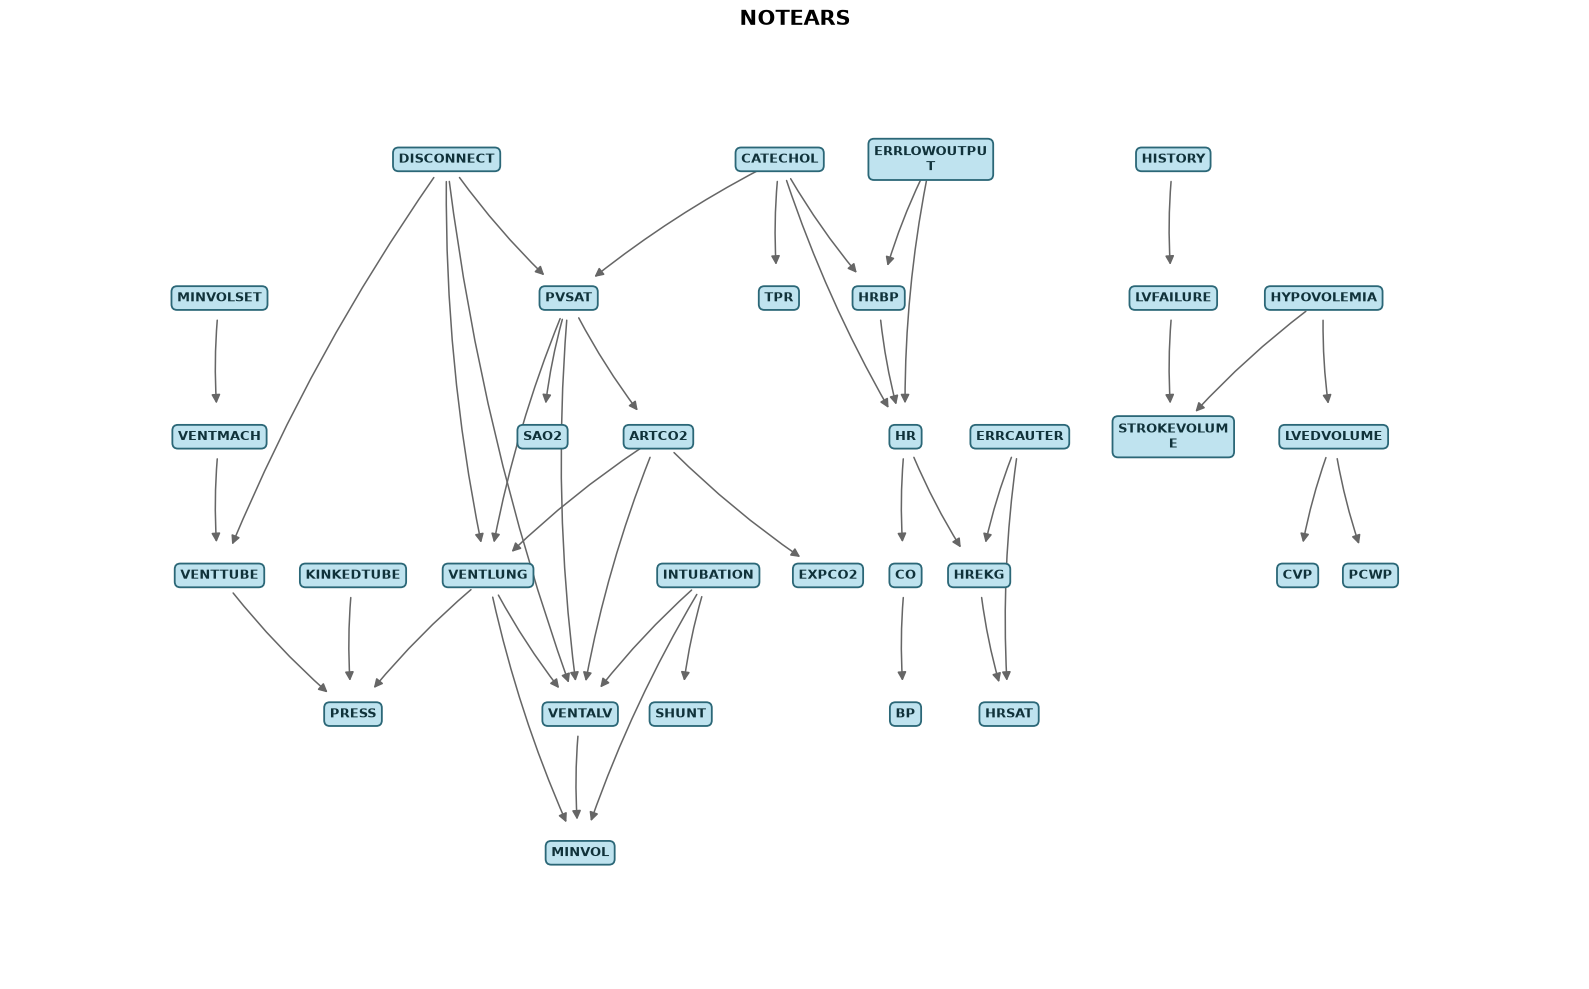

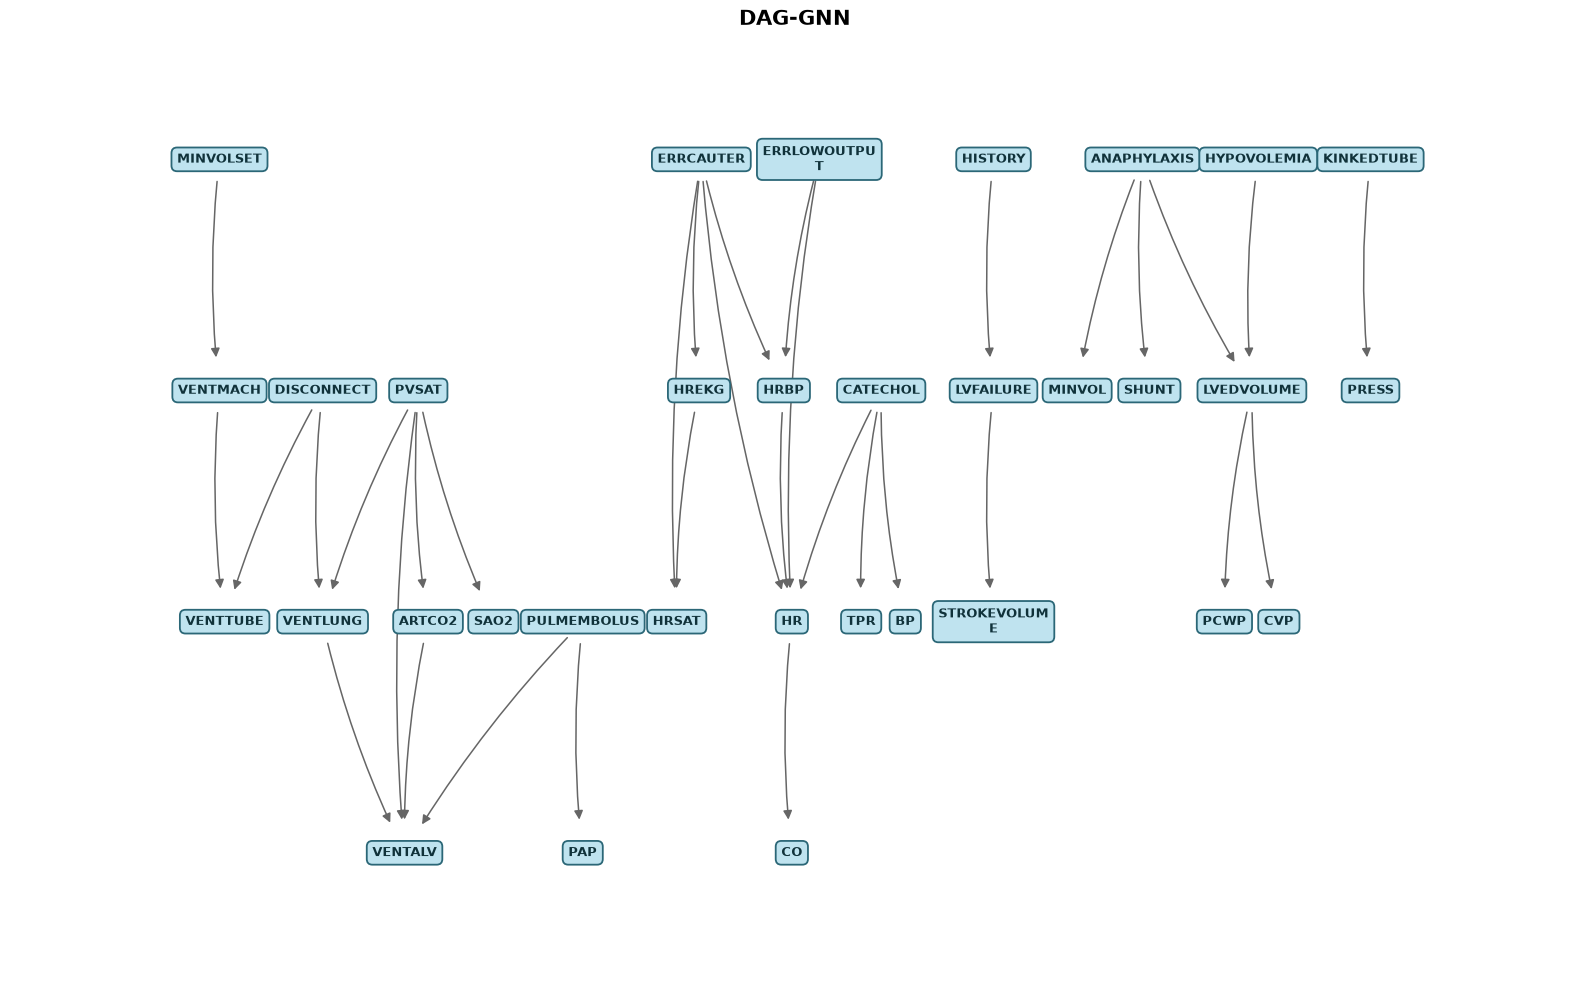

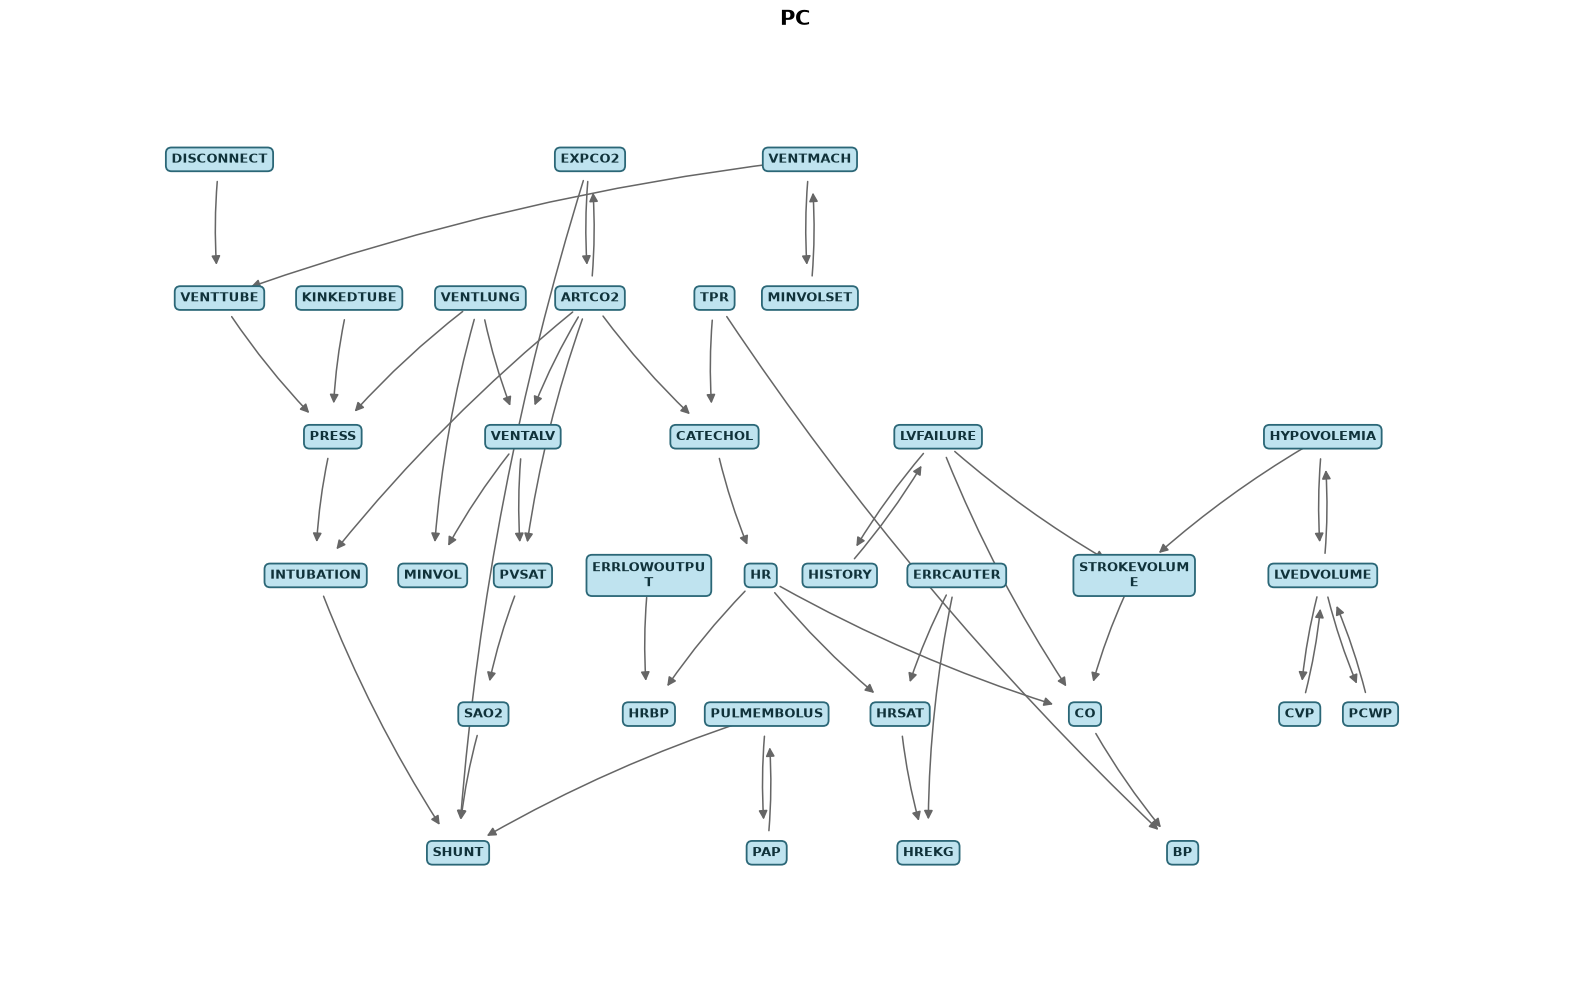

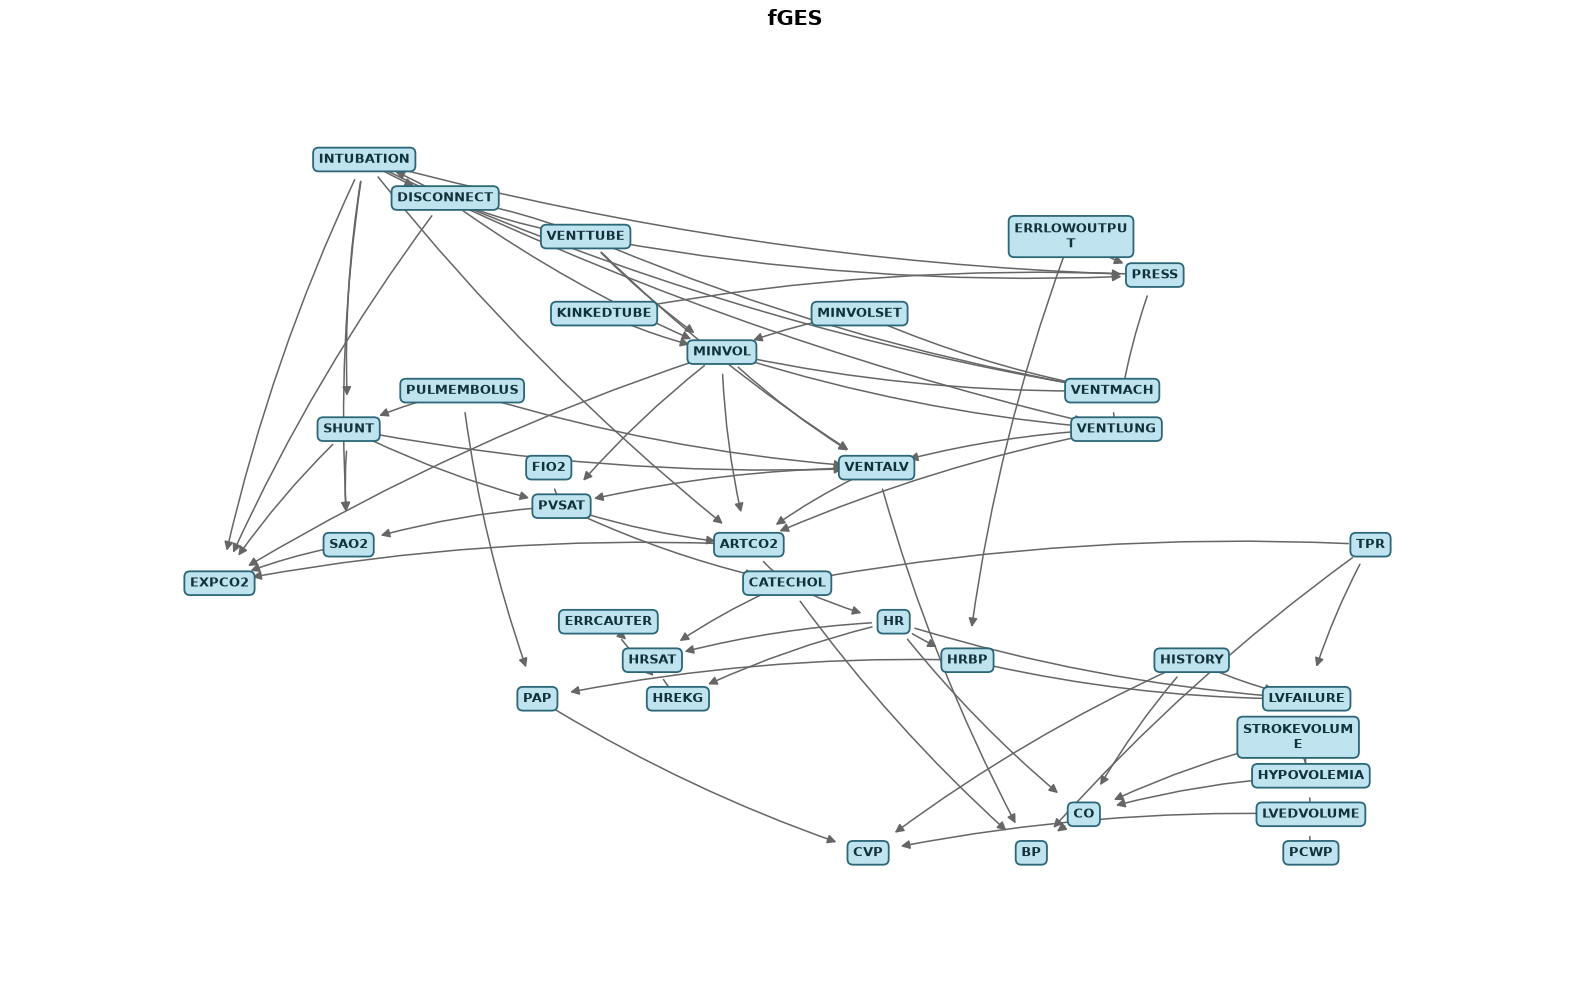

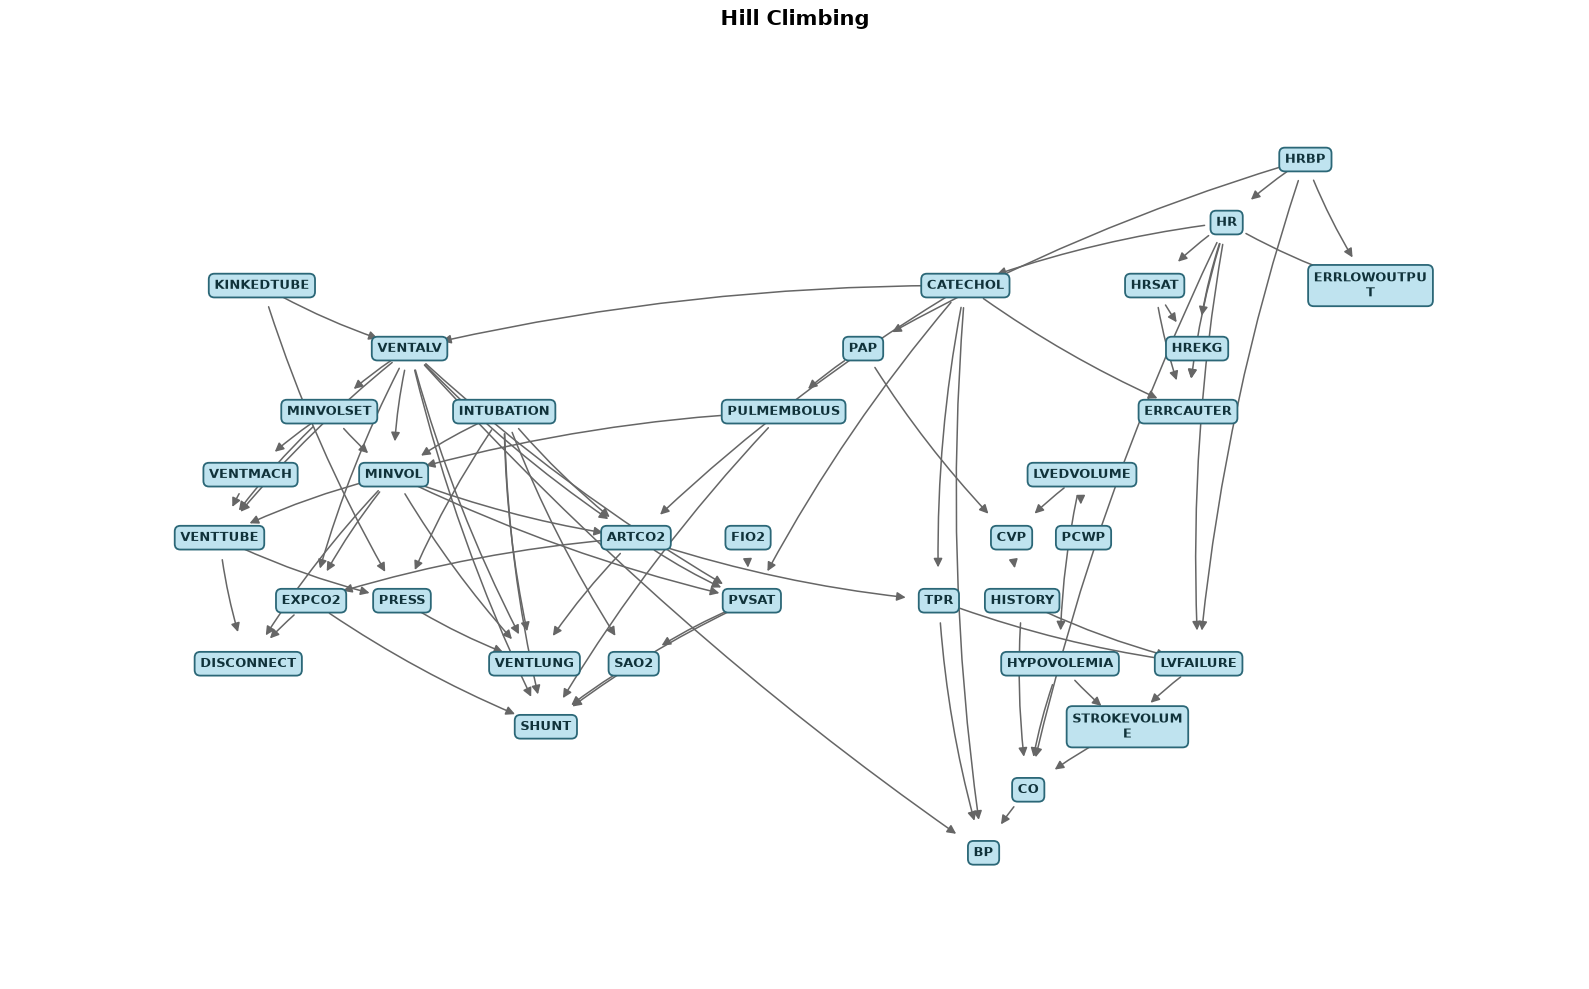

In [40]:
plot_dag(alarm_dag, "Alarm original DAG")
plot_dag(alarm_notears_result.edges, "NOTEARS")
plot_dag(alarm_daggnn_result.edges, "DAG-GNN")
plot_dag(alarm_pc_result.edges, "PC")
plot_dag(alarm_fges_result.edges, "fGES")
plot_dag(alarm_hc_result.edges, "Hill Climbing")